# Biometric Risk Factors for Heart Disease

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ x ] YES - make available
* [  ] NO - keep private

# Names

- Emery Goswami
- Nicole Hang
- Idris Ander
- Adha Syakhroza
- Annu Indraganti

# Abstract

Due to cultural tendencies it is commonly known that America has a consistent problem with obesity and heart related issues. We wanted to analyze heart disease because we understand that this is a prevalent issue in our society and we thought that it would be beneficial to understand how different variables related to heart disease varies between genders. We especially wanted to investigate these possible relationships to see if there are certain factors that influence heart disease in either men or women. We chose to use certain health metrics that are routinely measured including cholesterol, blood pressure, heart rate, presence of ECG abnormalities, and blood sugar.  We were able to achieve this by gathering four different data sets from the University of California Irvine Machine Learning Repository. We completed our analysis by first gathering all the data for the variables we wanted to analyze, after cleaning all of the data we then performed exploratory data analysis in order to visualize our data in a concise manner. We used statistical tests to determine whether there was a significant difference between heart disease and healthy patients for each of the variables. We also conducted these tests on male and female patient groups independently to determine if there was a difference in the relationships based on sex. We found that higher cholesterol, higher resting blood pressure, higher fasting blood sugar, and lower max heart rate were indicative of heart disease in both male and female patients. We also found that the presence of ECG abnormalities was only indicative of heart disease in male patients.

# Research Question

What biometric factors (such as cholesterol, heart rate, blood sugar) contribute to risk of heart disease and how do these factors differ between sexes?




## Background and Prior Work


Heart disease describes various conditions that affect the heart. The most common form of heart disease is coronary heart disease, a condition that restricts blood flow to the heart. This can increase risk for heart attacks, strokes, and other health issues. Heart disease is very prevalent, affecting millions of people in the U.S. each year, and is a leading cause of death. Thus, it is important to understand the possible factors that may play a role in increasing risk for heart disease. Since heart disease is complex to measure or predict, we would like to see if standard health metrics that can be easily measured during regular checkups can be used to indicate the presence of heart disease. This could make it easier to diagnose or predict the onset of heart disease. For our analysis, the metrics include resting heart rate, maximum heart rate, fasting blood sugar, cholesterol, and presence of resting electrocardiograph abnormalities.

Previous studies have been conducted to investigate various risk factors in heart disease. In one study reviewing how risk factors for heart disease affect male vs female patients, they found that heart disease had a higher prevalence in women.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) They stated that there were several female-specific risk factors from pregnancy and reproductive disorders. However, in a separate study, researchers analyzing cholesterol specifically as a risk factor in heart disease found that high cholesterol leads to a more detrimental risk of heart disease in men.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) In our project, we would like to further investigate the difference in heart disease risk factors between sexes to determine whether one sex is more adversely affected. We will expand our analysis to include more potential biometric risk factors such as blood sugar and heart rate in addition to cholesterol to get a more comprehensive overview of which factors may affect heart disease as well as how they may differ between sexes.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Appelman, Y., van Rijn, B. B., ten Haaf, M. E., Boersma, E., & Peters, S. A. E. (2015). Sex differences in cardiovascular risk factors and disease prevention. Atherosclerosis, 241(1), 211–218. https://doi.org/10.1016/j.atherosclerosis.2015.01.027 
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Peters, S. A. E., Singhateh, Y., Mackay, D., Huxley, R. R., & Woodward, M. (2016). Total cholesterol as a risk factor for coronary heart disease and stroke in women compared with men: A systematic review and meta-analysis. Atherosclerosis, 248, 123–131. https://doi.org/10.1016/j.atherosclerosis.2016.03.016 



# Hypothesis


We believe that if an individual has higher cholesterol, blood sugar, or heart rate, then they are at a higher risk of having a heart disease. This is because poor overall health metrics may weaken cardiovascular health. We predict each of the different factors may individually affect men and women differently due to genetic and biological differences that may contribute to proneness of heart disease.

# Data

## Data overview

For each dataset include the following information

- Dataset #1
  - Dataset Name: Cleveland Database
  - Link to the dataset: https://archive.ics.uci.edu/dataset/45/heart+disease
  - Number of observations: 303
  - Number of variables: 15
- Dataset #2
  - Dataset Name: Hungarian Database
  - Link to the dataset: https://archive.ics.uci.edu/dataset/45/heart+disease
  - Number of observations: 294
  - Number of variables: 15
- Dataset #3
  - Dataset Name: Switzerland Database
  - Link to the dataset: https://archive.ics.uci.edu/dataset/45/heart+disease
  - Number of observations: 123
  - Number of variables: 15
- Dataset #4
  - Dataset Name: VA Long Beach Database
  - Link to the dataset: https://archive.ics.uci.edu/dataset/45/heart+disease
  - Number of observations: 200
  - Number of variables: 15

Each dataset corresponds to a certain location and the data gathered from there. We joined the datasets into one dataframe. From the datasets, we have columns for demographic variables such as age (float) and sex (bool: (1-male, 0-female)). We also have columns for the biometric variables including trestbps (float: resting heart rate), chol (float: cholesterol in mg/dl), fbs (float: fasting blood sugar > 120 mg/dl (1-true, 0-false)), restecg (float: presence of resting ecg abnormalities (0-normal, 1-ST-T wave abnormality, 2- left ventricular hypertrophy), and thalach (float: max heart rate during stress test). Finally, we have the column num (float) which indicates the presence of heart disease where 0 is no heart disease and 1-4 is varying levels of heart disease. We removed columns with irrelevant variables.


## Dataset

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import ttest_ind

In [2]:
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

In [3]:
cleveland_df = pd.read_csv("heart_disease_data/processed.cleveland.data", delimiter=",", header=None)
cleveland_df.columns = columns
cleveland_df["location"] = "cleveland"
hungarian_df = pd.read_csv("heart_disease_data/processed.hungarian.data", header=None, delimiter=",")
hungarian_df.columns = columns
hungarian_df["location"] = "hungarian"
switzerland_df = pd.read_csv("heart_disease_data/processed.switzerland.data", header=None, delimiter=",")
switzerland_df.columns = columns
switzerland_df["location"] = "switzerland"
va_df = pd.read_csv("heart_disease_data/processed.va.data", header=None, delimiter=",")
va_df.columns = columns
va_df["location"] = "va_long_beach"

full_df = pd.concat([cleveland_df, hungarian_df, switzerland_df, va_df])
full_df = full_df.replace({"?": np.nan})
full_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,location
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


##### This shows us if the columns are of the proper data type. We see here that many are of object type when they should not be.

In [4]:
full_df.dtypes

age         float64
sex         float64
cp          float64
trestbps     object
chol         object
fbs          object
restecg      object
thalach      object
exang        object
oldpeak      object
slope        object
ca           object
thal         object
num           int64
location     object
dtype: object

##### This process cleans up the column data types. This process is shortened to make viewing the code nicer. The general process was to go through each column, get its unique values, choose a proper data type, and convert the column. Below is the code...

In [5]:
full_df["age"] = full_df["age"].astype(int)
full_df["sex"] = full_df["sex"].astype(int)
full_df["cp"] = full_df["cp"].astype(int)
full_df["trestbps"] = pd.to_numeric(full_df["trestbps"]).astype("Int32")
full_df["chol"] = pd.to_numeric(full_df["chol"]).astype("Int32")
full_df["fbs"] = pd.to_numeric(full_df["fbs"]).astype("Int16")
full_df["restecg"] = pd.to_numeric(full_df["restecg"]).astype("Int16")
full_df["thalach"] = pd.to_numeric(full_df["thalach"]).astype("Int32")
full_df["exang"] = pd.to_numeric(full_df["exang"]).astype("Int16")
full_df["oldpeak"] = pd.to_numeric(full_df["oldpeak"])
full_df["slope"] = pd.to_numeric(full_df["slope"]).astype("Int16")
full_df["ca"] = pd.to_numeric(full_df["ca"]).astype("Int16")
full_df["thal"] = pd.to_numeric(full_df["ca"]).astype("Int16")
full_df.dtypes

age           int64
sex           int64
cp            int64
trestbps      Int32
chol          Int32
fbs           Int16
restecg       Int16
thalach       Int32
exang         Int16
oldpeak     float64
slope         Int16
ca            Int16
thal          Int16
num           int64
location     object
dtype: object

##### Now that we have cleaned the data types, we need to see out missing value counts by row

In [6]:
all_na_df = full_df[full_df.isna().any(axis=1)]
f"The number of rows with missing values is {all_na_df.shape[0]} and the total number of rows is {full_df.shape[0]}"

'The number of rows with missing values is 619 and the total number of rows is 920'

##### Now we see them by column

In [7]:
na_percents = full_df.isna().mean()
na_percents

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.064130
chol        0.032609
fbs         0.097826
restecg     0.002174
thalach     0.059783
exang       0.059783
oldpeak     0.067391
slope       0.335870
ca          0.664130
thal        0.664130
num         0.000000
location    0.000000
dtype: float64

##### Looking at the column missing data, we see that there are three columns that have the most missing data. They are 'slope', 'ca', and 'thal'. 'slope' represents the direction of the ST segment during peak exercise. For a very general overview, we expect a healthy heart to have an upslope during peak exercise. A flat or downward slope could indicate heart disease. 'ca' is the number of heart vessels seen during fluroscopy. The higher this number is the better. It indicates there are most likely no blockages of these vessels. 'thal' represents 'thalassemia', a blood disorder that can affect blood flow to the heart. This data can definitely give us insight into understanding trends in heart disease diagnosis. To understand our missing data better, we will continue to explore.

In [8]:
slope_na = full_df.loc[full_df["slope"].isna()].groupby("location").agg("size")
slope_na

location
hungarian        190
switzerland       17
va_long_beach    102
dtype: int64

In [9]:
print(f"Percent Hungarian Data Missing: {slope_na['hungarian'] / hungarian_df.shape[0]}")
print(f"Percent VA Long Beach Data Missing: {slope_na['va_long_beach'] / va_df.shape[0]}")

Percent Hungarian Data Missing: 0.6462585034013606
Percent VA Long Beach Data Missing: 0.51


##### Removing roughly 64% of all Hungarian data and 51% of VA Long Beach data would not be a good idea. We would lose too much data and would constrict our analysis. Removing the column seems like the best course of action. This would remove some valuable information from our analysis, but it keeps our comparisons across different locations more even and unbiased, presenting us what we believe to be a sound decision.

In [10]:
no_slope_df = full_df.drop(columns="slope")
no_slope_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,thal,num,location
0,63,1,1,145,233,1,2,150,0,2.3,0,0,0,cleveland
1,67,1,4,160,286,0,2,108,1,1.5,3,3,2,cleveland
2,67,1,4,120,229,0,2,129,1,2.6,2,2,1,cleveland
3,37,1,3,130,250,0,0,187,0,3.5,0,0,0,cleveland
4,41,0,2,130,204,0,2,172,0,1.4,0,0,0,cleveland


##### Now let us do a similar approach for the other two columns. We will now begin the 'ca' analysis.

In [11]:
ca_na = no_slope_df.loc[no_slope_df["ca"].isna()].groupby("location").agg("size")
ca_na

location
cleveland          4
hungarian        291
switzerland      118
va_long_beach    198
dtype: int64

In [12]:
print(f"Percent Missing of Hungarian: {ca_na['hungarian'] / hungarian_df.shape[0]}")
print(f"Percent Missing of Switzerland: {ca_na['switzerland'] / switzerland_df.shape[0]}")
print(f"Percent Missing of VA Long Beach: {ca_na['va_long_beach'] / va_df.shape[0]}")

Percent Missing of Hungarian: 0.9897959183673469
Percent Missing of Switzerland: 0.959349593495935
Percent Missing of VA Long Beach: 0.99


##### This seems to present similar logic to the previous analysis. With such a high amount of missing values, keeping this column would not make sense. Therefore, removing it is the course of action we took. This once again would remove some valuable information from our analysis, but with such a high relative percent of missing values, we may have generalized to a wider population when really a majority of the data analysis of this column would be based on Cleveland. 

In [13]:
no_ca_df = no_slope_df.drop(columns="ca")
no_slope_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,thal,num,location
0,63,1,1,145,233,1,2,150,0,2.3,0,0,0,cleveland
1,67,1,4,160,286,0,2,108,1,1.5,3,3,2,cleveland
2,67,1,4,120,229,0,2,129,1,2.6,2,2,1,cleveland
3,37,1,3,130,250,0,0,187,0,3.5,0,0,0,cleveland
4,41,0,2,130,204,0,2,172,0,1.4,0,0,0,cleveland


##### Now we continue to the 'thal' column

In [14]:
thal_na = no_ca_df.loc[no_ca_df["thal"].isna()].groupby("location").agg("size")
thal_na

location
cleveland          4
hungarian        291
switzerland      118
va_long_beach    198
dtype: int64

##### These numbers look the exact same as the 'ca' column. Let's see if the indices are matching up. 

In [15]:
ca_na_index = full_df.loc[full_df["ca"].isna()].index
thal_na_index = full_df.loc[full_df["thal"].isna()].index
ca_na_index.isin(thal_na_index).mean()

1.0

##### We see that every missing 'ca' index matches up with every missing 'thal' index. This means that if 'ca' is missing from a row, then it will have a missing 'thal' value. As such, our logic remains the same as above, leading to us removing this column from analysis. 

In [16]:
no_thal_df = no_ca_df.drop(columns="thal")
no_thal_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num,location
0,63,1,1,145,233,1,2,150,0,2.3,0,cleveland
1,67,1,4,160,286,0,2,108,1,1.5,2,cleveland
2,67,1,4,120,229,0,2,129,1,2.6,1,cleveland
3,37,1,3,130,250,0,0,187,0,3.5,0,cleveland
4,41,0,2,130,204,0,2,172,0,1.4,0,cleveland


##### Now let's see the rest of the missing data data

In [17]:
new_na_percents = no_thal_df.isna().mean()
new_na_percents

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.064130
chol        0.032609
fbs         0.097826
restecg     0.002174
thalach     0.059783
exang       0.059783
oldpeak     0.067391
num         0.000000
location    0.000000
dtype: float64

In [18]:
na_df = no_thal_df[no_thal_df.isna().any(axis=1)]
f"Percent Missing Data Rows: {na_df.shape[0] / no_thal_df.shape[0]}"

'Percent Missing Data Rows: 0.1956521739130435'

##### There is still a lot of rows with missing data. We will start with the 'trestbps' column and work our way down. However, we also decided to narrow down our column choice as a group. We decided the most informative columns, based on description given about our dataset, were [age, sex, trestbps, chol, fbs, restecg, thalach, num, and cp]. The columns we deemed irrelevent were 'exang', and 'oldpeak' (from this point in the analysis after the missing value dropping that occured above). These columns were based on stress testing, where we felt had too many confounding factors that would for correlating to the presence of heart disease (such as someone who just doesn't exercise). Therefore, these columns were removed.

In [19]:
no_thal_df = no_thal_df.drop(columns=["exang", "oldpeak"])
no_thal_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,num,location
0,63,1,1,145,233,1,2,150,0,cleveland
1,67,1,4,160,286,0,2,108,2,cleveland
2,67,1,4,120,229,0,2,129,1,cleveland
3,37,1,3,130,250,0,0,187,0,cleveland
4,41,0,2,130,204,0,2,172,0,cleveland
...,...,...,...,...,...,...,...,...,...,...
195,54,0,4,127,333,1,1,154,1,va_long_beach
196,62,1,1,<NA>,139,0,1,<NA>,0,va_long_beach
197,55,1,4,122,223,1,1,100,2,va_long_beach
198,58,1,4,<NA>,385,1,2,<NA>,0,va_long_beach


In [20]:
na_trestbps = no_thal_df.loc[no_thal_df['trestbps'].isna()].groupby("location").agg("size")
na_trestbps

location
hungarian         1
switzerland       2
va_long_beach    56
dtype: int64

##### Seems VA Long Beach has most of the missing values. However, trestbps is an extremely valuable piece of information related to heart health, representing the resting heart rate of an individual. Simply removing this column would be bad for our analysis. Therefore, we would like to try another solution. 

Text(0, 0.5, 'Density')

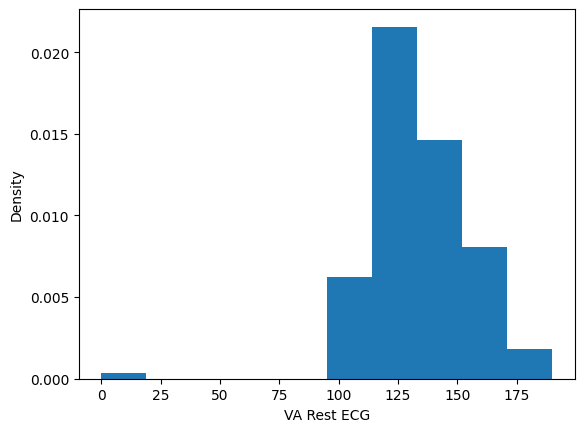

In [21]:
clean_va_trest = no_thal_df.loc[(~no_thal_df["trestbps"].isna()) & (no_thal_df["location"] == "va_long_beach"), "trestbps"]
plt.hist(clean_va_trest, density=True)
plt.xlabel("VA Rest ECG")
plt.ylabel("Density")

Text(0, 0.5, 'Density')

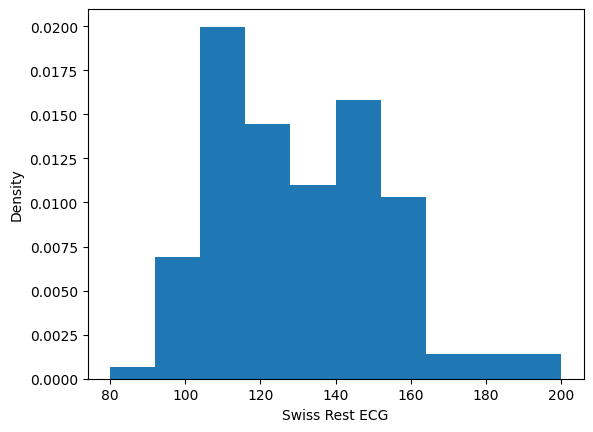

In [22]:
clean_swiss_trest = no_thal_df.loc[(~no_thal_df["trestbps"].isna()) & (no_thal_df["location"] == "switzerland"), "trestbps"]
plt.hist(clean_swiss_trest, density=True)
plt.xlabel("Swiss Rest ECG")
plt.ylabel("Density")

Text(0, 0.5, 'Density')

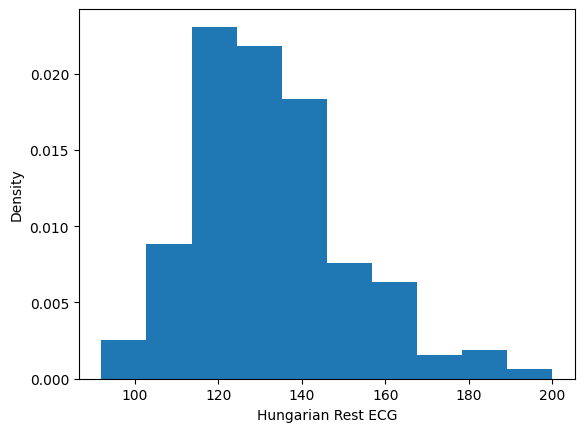

In [23]:
clean_hun_trest = no_thal_df.loc[(~no_thal_df["trestbps"].isna()) & (no_thal_df["location"] == "hungarian"), "trestbps"]
plt.hist(clean_hun_trest, density=True)
plt.xlabel("Hungarian Rest ECG")
plt.ylabel("Density")

##### We have some weird low outliers in the VA Long Beach data. Let's explore this.

In [24]:
clean_va_trest[clean_va_trest < 75]

33    0
Name: trestbps, dtype: Int32

In [25]:
no_thal_df = no_thal_df.drop(33)
no_thal_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,num,location
0,63,1,1,145,233,1,2,150,0,cleveland
1,67,1,4,160,286,0,2,108,2,cleveland
2,67,1,4,120,229,0,2,129,1,cleveland
3,37,1,3,130,250,0,0,187,0,cleveland
4,41,0,2,130,204,0,2,172,0,cleveland


##### A single person has outlier data. Removing this from our dataset should allow us to remove an improper record while preserving our data integrity.

Text(0, 0.5, 'Density')

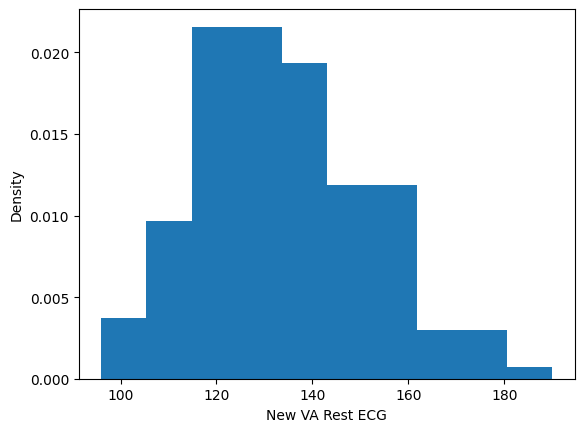

In [26]:
clean_va_trest = no_thal_df.loc[(~no_thal_df["trestbps"].isna()) & (no_thal_df["location"] == "va_long_beach"), "trestbps"]
plt.hist(clean_va_trest, density=True)
plt.xlabel("New VA Rest ECG")
plt.ylabel("Density")

##### For data across locations, we see all are roughly normal. We could try and randomly sample from a normal distribution of the same dimensions and impute this data. 

In [27]:
va_trest = no_thal_df.loc[no_thal_df["location"] == "va_long_beach", "trestbps"]

In [28]:
swiss_trest = no_thal_df.loc[no_thal_df["location"] == "switzerland", "trestbps"]

In [29]:
hun_trest = no_thal_df.loc[no_thal_df["location"] == "hungarian", "trestbps"]

In [30]:
mu = va_trest.mean()
std = va_trest.std()
missing_va_trest_i = no_thal_df.loc[(no_thal_df["trestbps"].isna()) & (no_thal_df["location"] == "va_long_beach")].index
sampled_vals = np.random.normal(mu, std, size = len(missing_va_trest_i)).astype(int)
no_thal_df.loc[(no_thal_df["trestbps"].isna()) & (no_thal_df["location"] == "va_long_beach"), "trestbps"] = sampled_vals

In [31]:
mu = swiss_trest.mean()
std = swiss_trest.std()
missing_swiss_trest_i = no_thal_df.loc[(no_thal_df["trestbps"].isna()) & (no_thal_df["location"] == "switzerland")].index
sampled_vals = np.random.normal(mu, std, size = len(missing_swiss_trest_i)).astype(int)
no_thal_df.loc[(no_thal_df["trestbps"].isna()) & (no_thal_df["location"] == "switzerland"), "trestbps"] = sampled_vals

In [32]:
mu = hun_trest.mean()
std = hun_trest.std()
missing_hun_trest_i = no_thal_df.loc[(no_thal_df["trestbps"].isna()) & (no_thal_df["location"] == "hungarian")].index
sampled_vals = np.random.normal(mu, std, size = len(missing_hun_trest_i)).astype(int)
no_thal_df.loc[(no_thal_df["trestbps"].isna()) & (no_thal_df["location"] == "hungarian"), "trestbps"] = sampled_vals

In [33]:
new_na_percents = no_thal_df.isna().mean()
new_na_percents

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.032751
fbs         0.097162
restecg     0.002183
thalach     0.060044
num         0.000000
location    0.000000
dtype: float64

##### There is a lot of improvement in missing data for trestbps. Let's continue to 'chol'.

In [34]:
na_chol = no_thal_df.loc[no_thal_df["chol"].isna()].groupby("location").agg("size")
na_chol

location
hungarian        23
va_long_beach     7
dtype: int64

Text(0, 0.5, 'Density')

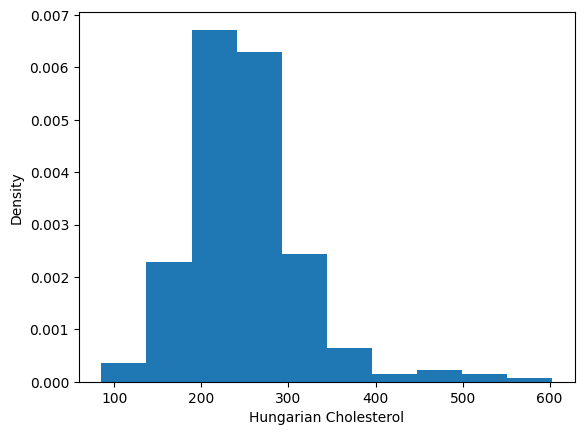

In [35]:
hun_no_missing_chol = no_thal_df.loc[(~no_thal_df["chol"].isna()) & (no_thal_df["location"] == "hungarian"), "chol"]
plt.hist(hun_no_missing_chol, density=True)
plt.xlabel("Hungarian Cholesterol")
plt.ylabel("Density")

Text(0, 0.5, 'Density')

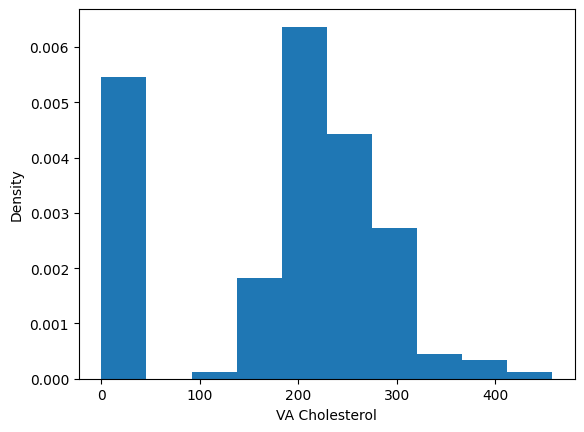

In [36]:
va_no_missing_chol = no_thal_df.loc[(~no_thal_df["chol"].isna()) & (no_thal_df["location"] == "va_long_beach"), "chol"]
plt.hist(va_no_missing_chol, density=True)
plt.xlabel("VA Cholesterol")
plt.ylabel("Density")

Text(0.5, 1.0, 'Hungarian Cholesterol Box Plot')

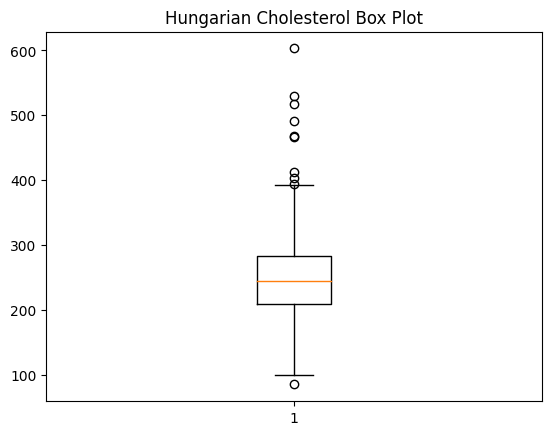

In [37]:
plt.boxplot(hun_no_missing_chol)
plt.title("Hungarian Cholesterol Box Plot")

Text(0.5, 1.0, 'VA Cholesterol Good Data Box Plot')

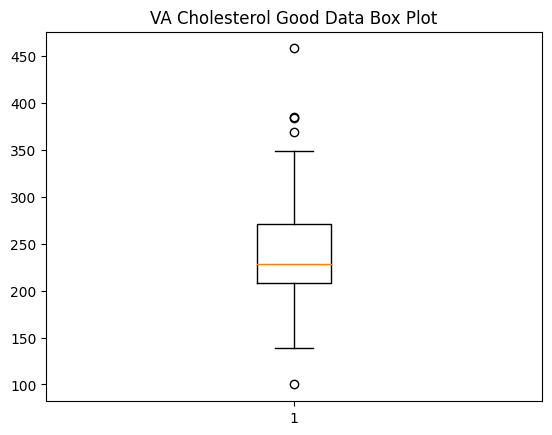

In [38]:
plt.boxplot(va_no_missing_chol[va_no_missing_chol > 0])
plt.title("VA Cholesterol Good Data Box Plot")

In [39]:
print(f"Fraction of Outliers Hungary: {len(hun_no_missing_chol[hun_no_missing_chol > 400]) + 1} / {len(hun_no_missing_chol)}")
print(f"Fraction of Zeros in VA: {1 - np.mean(va_no_missing_chol > 0)}")

Fraction of Outliers Hungary: 9 / 270
Fraction of Zeros in VA: 0.25


##### From above, we can see the Hungary sub-distribution has outliers while there is strange 0 data for the VA sub-distribution. We need to fix all of this. Let's begin...

Text(0, 0.5, 'Density')

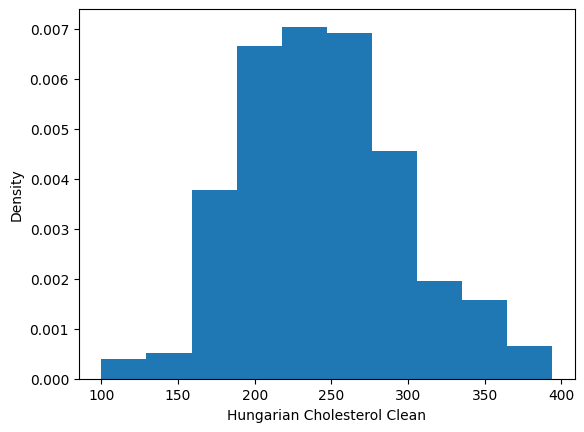

In [40]:
clean_hun_chol = hun_no_missing_chol[~(hun_no_missing_chol > 400) & ~(hun_no_missing_chol < 100)]
plt.hist(clean_hun_chol, density=True)
plt.xlabel("Hungarian Cholesterol Clean")
plt.ylabel("Density")

Text(0, 0.5, 'Density')

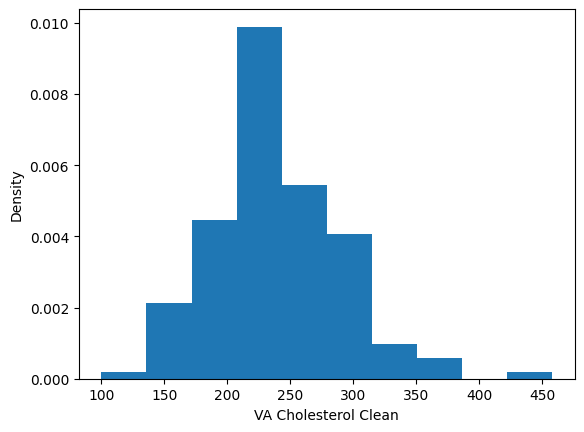

In [41]:
clean_va_chol = va_no_missing_chol[~(va_no_missing_chol == 0)]
plt.hist(clean_va_chol, density=True)
plt.xlabel("VA Cholesterol Clean")
plt.ylabel("Density")

##### This data seems to be normally distributed in both sub-distributions. Let's impute the missing values.

In [42]:
missing_hun_i = no_thal_df.loc[(no_thal_df["location"] == "hungarian") & (no_thal_df["chol"].isna())].index
sampled_vals = np.random.normal(clean_hun_chol.mean(), clean_hun_chol.std(), size=len(missing_hun_i)).astype(int)
no_thal_df.loc[(no_thal_df["location"] == "hungarian") & (no_thal_df["chol"].isna()), "chol"] = sampled_vals
no_thal_df["chol"].isna().mean()

0.007641921397379912

In [43]:
missing_va_i = no_thal_df.loc[(no_thal_df["location"] == "va_long_beach") & (no_thal_df["chol"].isna())].index
sampled_vals = np.random.normal(clean_va_chol.mean(), clean_va_chol.std(), size=len(missing_va_i)).astype(int)
no_thal_df.loc[(no_thal_df["location"] == "va_long_beach") & (no_thal_df["chol"].isna()), "chol"] = sampled_vals
no_thal_df["chol"].isna().mean()

0.0

In [44]:
missing_va_i = no_thal_df.loc[(no_thal_df["location"] == "va_long_beach") & (no_thal_df["chol"] == 0)].index
sampled_vals = np.random.normal(clean_va_chol.mean(), clean_va_chol.std(), size=len(missing_va_i)).astype(int)
no_thal_df.loc[(no_thal_df["location"] == "va_long_beach") & (no_thal_df["chol"] == 0), "chol"] = sampled_vals

In [45]:
missing_va_i = no_thal_df.loc[(no_thal_df["location"] == "va_long_beach") & (no_thal_df["chol"] == 0)].index
sampled_vals = np.random.normal(clean_va_chol.mean(), clean_va_chol.std(), size=len(missing_va_i)).astype(int)
no_thal_df.loc[(no_thal_df["location"] == "va_long_beach") & (no_thal_df["chol"] == 0), "chol"] = sampled_vals

##### There does not seem to be any real Switzerland cholesterol numbers. This presents an interesting issue. Discount the rows seems rash but keeping such a large amount of 0s is also not in our best interest. We decided to impute these values based on the global distribution instead (excluding Swiss). This felt like the best way to maintain the integrity of our data without removing an entire column or set of rows. Since cholesterol is very important to our question, we felt this was the course of action that was most appropriate.However, in EDA, we want to take this lack of data into account. It is currently a placeholder and would like further instruction on what to do here.

In [46]:
chol_col = no_thal_df["chol"]
chol_col = chol_col[chol_col > 0]
g_chol_mean = chol_col.mean()
g_chol_std = chol_col.std()
length = len(no_thal_df.loc[(no_thal_df["location"] == "switzerland") & (no_thal_df["chol"] == 0), "chol"])
sampled_vals = np.random.normal(g_chol_mean, g_chol_std, size=length).astype(int)
no_thal_df.loc[(no_thal_df["location"] == "switzerland") & (no_thal_df["chol"] == 0), "chol"] = sampled_vals

In [47]:
np.mean(no_thal_df["chol"] == 0)

0.0

In [48]:
new_na_percents = no_thal_df.isna().mean()
new_na_percents

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.097162
restecg     0.002183
thalach     0.060044
num         0.000000
location    0.000000
dtype: float64

##### For 'fbs', we have a boolean variable. Dropping isn't practical since fasting blood sugar does provide extremely valuable information for our research question. For this reason, we went with sampling from a Bernouli distribution with the locations sub-proportions. This cleans the issue data.

In [49]:
fbs_na = no_thal_df.loc[no_thal_df["fbs"].isna()].groupby("location").agg("size")
fbs_na

location
hungarian         8
switzerland      74
va_long_beach     7
dtype: int64

In [50]:
fbs_swiss = no_thal_df.loc[(no_thal_df["location"] == "switzerland") & ~(no_thal_df["fbs"].isna()), "fbs"]
true = fbs_swiss.mean()
missing_i = no_thal_df.loc[(no_thal_df["location"] == "switzerland") & (no_thal_df["fbs"].isna()), "fbs"].index
sampled_vals = np.random.binomial(n=1, p=true, size=len(missing_i))
no_thal_df.loc[(no_thal_df["location"] == "switzerland") & (no_thal_df["fbs"].isna()), "fbs"] = sampled_vals
no_thal_df["fbs"].isna().mean()

0.016375545851528384

In [51]:
fbs_hun = no_thal_df.loc[(no_thal_df["location"] == "hungarian") & ~(no_thal_df["fbs"].isna()), "fbs"]
true = fbs_hun.mean()
missing_i = no_thal_df.loc[(no_thal_df["location"] == "hungarian") & (no_thal_df["fbs"].isna()), "fbs"].index
sampled_vals = np.random.binomial(n=1, p=true, size=len(missing_i))
no_thal_df.loc[(no_thal_df["location"] == "hungarian") & (no_thal_df["fbs"].isna()), "fbs"] = sampled_vals
no_thal_df["fbs"].isna().mean()

0.007641921397379912

In [52]:
fbs_va = no_thal_df.loc[(no_thal_df["location"] == "va_long_beach") & ~(no_thal_df["fbs"].isna()), "fbs"]
true = fbs_va.mean()
missing_i = no_thal_df.loc[(no_thal_df["location"] == "va_long_beach") & (no_thal_df["fbs"].isna()), "fbs"].index
sampled_vals = np.random.binomial(n=1, p=true, size=len(missing_i))
no_thal_df.loc[(no_thal_df["location"] == "va_long_beach") & (no_thal_df["fbs"].isna()), "fbs"] = sampled_vals
no_thal_df["fbs"].isna().mean()

0.0

##### For 'thalach', we once again have numerical data we can potentially impute with. Most of the missing data is from VA Long Beach. Let's see what we can see from some EDA.

In [53]:
na_thalach = no_thal_df.loc[no_thal_df["thalach"].isna()].groupby("location").agg("size")
na_thalach

location
hungarian         1
switzerland       1
va_long_beach    53
dtype: int64

Text(0, 0.5, 'Density')

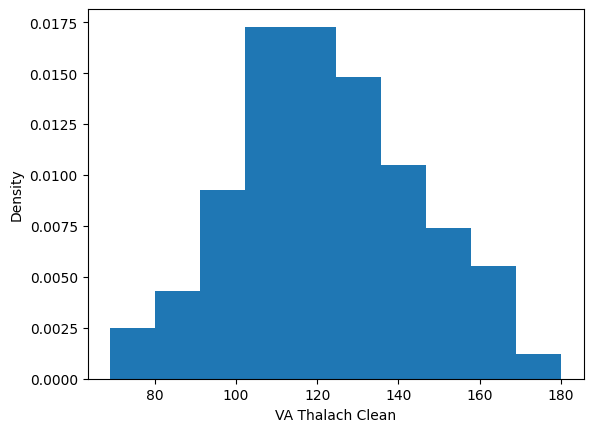

In [54]:
clean_va_thal = no_thal_df.loc[~(no_thal_df["thalach"].isna()) & (no_thal_df["location"] == "va_long_beach"), "thalach"]
plt.hist(clean_va_thal, density=True)
plt.xlabel("VA Thalach Clean")
plt.ylabel("Density")

Text(0, 0.5, 'Density')

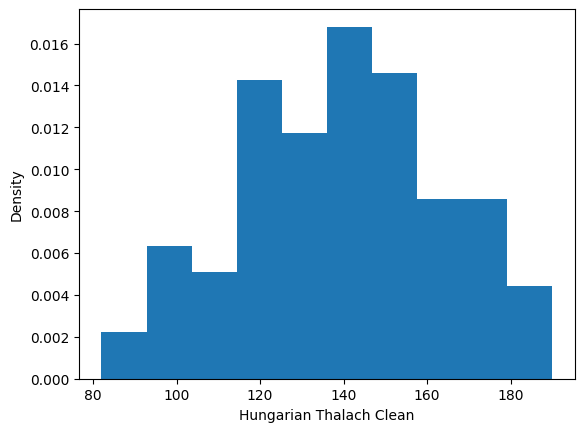

In [55]:
clean_hun_thal = no_thal_df.loc[~(no_thal_df["thalach"].isna()) & (no_thal_df["location"] == "hungarian"), "thalach"]
plt.hist(clean_hun_thal, density=True)
plt.xlabel("Hungarian Thalach Clean")
plt.ylabel("Density")

Text(0, 0.5, 'Density')

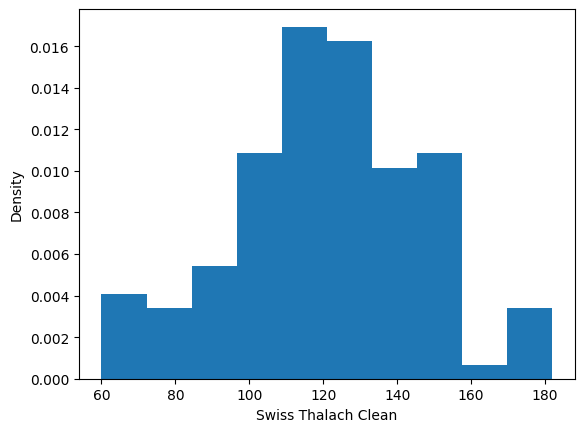

In [56]:
clean_swiss_thal = no_thal_df.loc[~(no_thal_df["thalach"].isna()) & (no_thal_df["location"] == "switzerland"), "thalach"]
plt.hist(clean_swiss_thal, density=True)
plt.xlabel("Swiss Thalach Clean")
plt.ylabel("Density")

##### Once again, we have roughly normal distributions. Can can try using these sample parameters to try and impute the data that is missing.

In [57]:
mu = clean_va_thal.mean()
std = clean_va_thal.std()
missing_i = no_thal_df.loc[(no_thal_df["thalach"].isna()) & (no_thal_df["location"] == "va_long_beach"), "thalach"].index
sampled_vals = np.random.normal(mu, std, size=len(missing_i)).astype(int)
no_thal_df.loc[(no_thal_df["thalach"].isna()) & (no_thal_df["location"] == "va_long_beach"), "thalach"] = sampled_vals
no_thal_df["thalach"].isna().mean()

0.002183406113537118

In [58]:
mu = clean_hun_thal.mean()
std = clean_hun_thal.std()
missing_i = no_thal_df.loc[(no_thal_df["thalach"].isna()) & (no_thal_df["location"] == "hungarian"), "thalach"].index
sampled_vals = np.random.normal(mu, std, size=len(missing_i)).astype(int)
no_thal_df.loc[(no_thal_df["thalach"].isna()) & (no_thal_df["location"] == "hungarian"), "thalach"] = sampled_vals
no_thal_df["thalach"].isna().mean()

0.001091703056768559

In [59]:
mu = clean_swiss_thal.mean()
std = clean_swiss_thal.std()
missing_i = no_thal_df.loc[(no_thal_df["thalach"].isna()) & (no_thal_df["location"] == "switzerland"), "thalach"].index
sampled_vals = np.random.normal(mu, std, size=len(missing_i)).astype(int)
no_thal_df.loc[(no_thal_df["thalach"].isna()) & (no_thal_df["location"] == "switzerland"), "thalach"] = sampled_vals
no_thal_df["thalach"].isna().mean()

0.0

In [60]:
new_na_percents = no_thal_df.isna().mean()
new_na_percents

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.000000
restecg     0.002183
thalach     0.000000
num         0.000000
location    0.000000
dtype: float64

In [61]:
no_thal_df.restecg.unique()

<IntegerArray>
[2, 0, 1, <NA>]
Length: 4, dtype: Int16

##### Lastly for 'restecg', we have a categorical variable. Imputing this becomes significantly more tricky since we cannot see the underlying distribution. Therefore, we decided to drop these rows instead. Forunately, there are only two rows to drop, making our loss of data inconsequential. 

In [62]:
na_ecg = no_thal_df.loc[no_thal_df["restecg"].isna()]
final_df = no_thal_df.drop(na_ecg.index)
print(f"Number of Missing Values in Rows: {final_df[final_df.isna().any(axis=1)].shape[0]}")
final_df.head()

Number of Missing Values in Rows: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,num,location
0,63,1,1,145,233,1,2,150,0,cleveland
2,67,1,4,120,229,0,2,129,1,cleveland
3,37,1,3,130,250,0,0,187,0,cleveland
4,41,0,2,130,204,0,2,172,0,cleveland
5,56,1,2,120,236,0,0,178,0,cleveland


##### We dropped this column since it did not fit well with our research question. This is elaborated upon in other sections. 

In [63]:
final_df = final_df.drop(columns="cp")

In [64]:
final_df.to_csv("data.csv")

##### This reads in each dataset, defines its columns, adds its location, and appends all of the datasets into a single large dataframe. After, we properly represent the "na" values and display the results.

In [65]:
columns = ['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'num', 'location']
num_columns = ['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'num']

In [66]:
df = pd.read_csv("data.csv", delimiter=",", header=None)
df.head()

df = df.drop(columns=[0])
df.columns = columns
df = df.drop(index=0).reset_index(drop=True)

df = df.replace({"?": np.nan})
df = df.dropna()
df[num_columns] = df[num_columns].apply(pd.to_numeric, errors='coerce')
df['sex'] = df['sex'].map({1: 'Man', 0: 'Woman'})

df.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,num,location
0,63,Man,145,233,1,2,150,0,cleveland
1,67,Man,120,229,0,2,129,1,cleveland
2,37,Man,130,250,0,0,187,0,cleveland
3,41,Woman,130,204,0,2,172,0,cleveland
4,56,Man,120,236,0,0,178,0,cleveland


# Results

## Exploratory Data Analysis

### EDA Summary Statistics:

In [67]:
#Summary of the Data
df.describe()

,age,trestbps,chol,fbs,restecg,thalach,num
count,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000
mean,53.579121,132.367033,246.598901,0.163736,0.605495,136.486813,0.996703
std,9.377653,18.598219,58.876562,0.370240,0.806582,25.997532,1.144648
min,28.000000,80.000000,85.000000,0.000000,0.000000,60.000000,0.000000
25%,47.000000,120.000000,209.000000,0.000000,0.000000,119.000000,0.000000
50%,54.000000,130.000000,241.000000,0.000000,0.000000,138.000000,1.000000
75%,60.000000,142.000000,279.750000,0.000000,1.000000,156.000000,2.000000
max,77.000000,200.000000,603.000000,1.000000,2.000000,202.000000,4.000000


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 910 entries, 0 to 909
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       910 non-null    int64 
 1   sex       910 non-null    object
 2   trestbps  910 non-null    int64 
 3   chol      910 non-null    int64 
 4   fbs       910 non-null    int64 
 5   restecg   910 non-null    int64 
 6   thalach   910 non-null    int64 
 7   num       910 non-null    int64 
 8   location  910 non-null    object
dtypes: int64(7), object(2)
memory usage: 64.1+ KB


### EDA Data Visualization:

### Cholesterol

The following two graphs show overall cholesterol levels and cholesterol levels in men and women. As shown below there is a normal distribution of choletrol levels across both sexes. There was a spike of datapoints that were labeled 0 for cholesterol so these datapoints were removed in datacleaning above. Below is a final visualization of cholesterol data.

Text(0.5, 1.0, 'Cholesterol Levels')

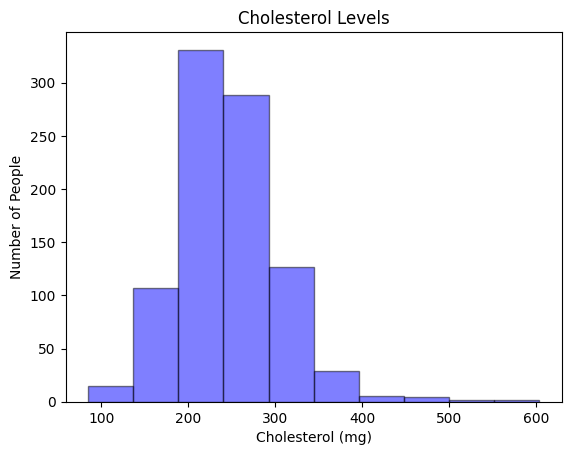

In [69]:
plt.hist(df['chol'], bins=10, alpha=0.5, color='blue', edgecolor='black')
plt.xlabel("Cholesterol (mg)")
plt.ylabel("Number of People")
plt.title("Cholesterol Levels")

/var/folders/lb/qd9dqmgn54j3m3g4xg4cyzx00000gn/T/ipykernel_81173/3490679539.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='chol', data=df, palette={'Man': '#87CEEB', 'Woman': 'red'}, linewidth=2.5)


Text(0, 0.5, 'Cholesterol (mg)')

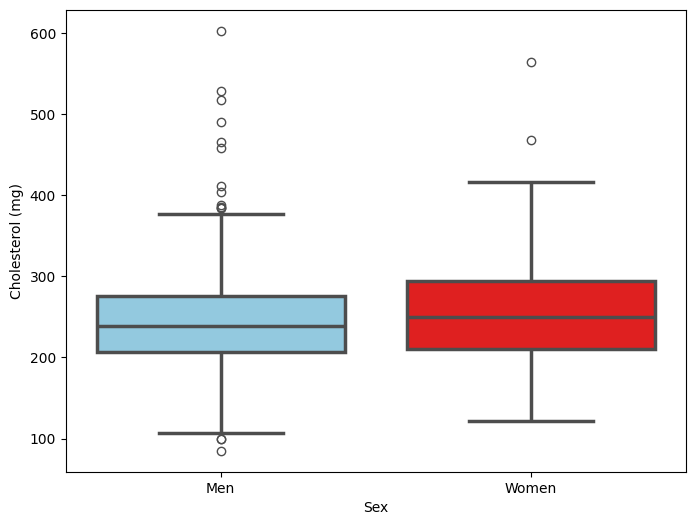

In [70]:
import seaborn as sns

df = df[df['chol'] != 0]
plt.figure(figsize=(8,6))
sns.boxplot(x='sex', y='chol', data=df, palette={'Man': '#87CEEB', 'Woman': 'red'}, linewidth=2.5)
plt.xticks(ticks=[0, 1], labels=['Men', 'Women'])

plt.xlabel("Sex")
plt.ylabel("Cholesterol (mg)")

### Resting Blood Pressure

In this section of our experiment we are analyzing the relationship of the resting blood pressure between men and women. As we can see in our graphs that we can observe that more men tend to have a higher resting blood pressure. 

/var/folders/lb/qd9dqmgn54j3m3g4xg4cyzx00000gn/T/ipykernel_81173/1895425434.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='trestbps', data=df, palette={'Man': '#87CEEB', 'Woman': 'red'}, linewidth=2.5)


Text(0, 0.5, 'Resting Blood Pressure (mmHg)')

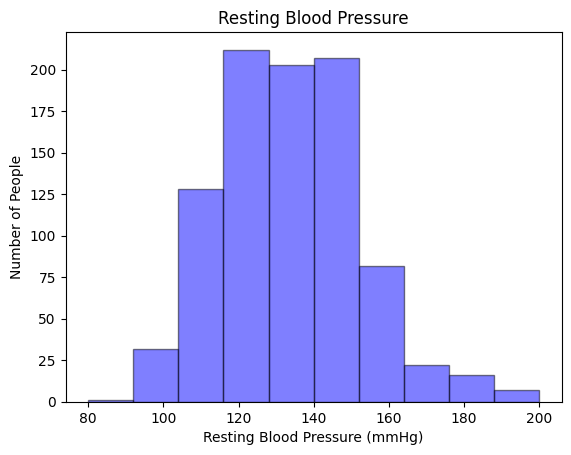

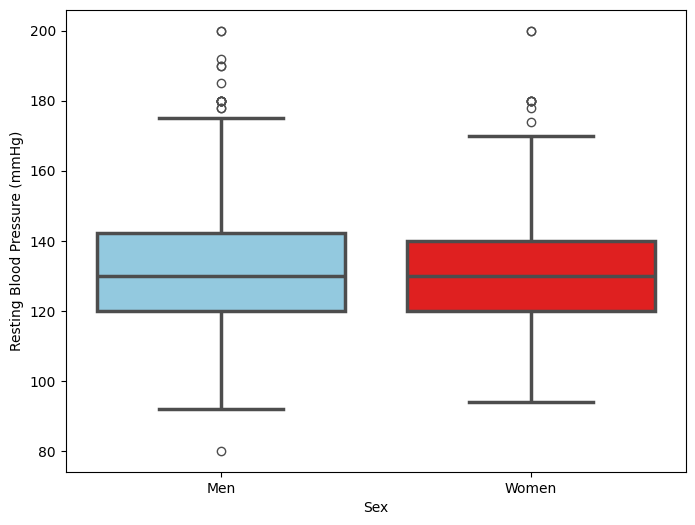

In [71]:
plt.hist(df['trestbps'], bins=10, alpha=0.5, color='blue', edgecolor='black')
plt.xlabel("Resting Blood Pressure (mmHg)")
plt.ylabel("Number of People")
plt.title("Resting Blood Pressure")
plt.figure(figsize=(8,6))
sns.boxplot(x='sex', y='trestbps', data=df, palette={'Man': '#87CEEB', 'Woman': 'red'}, linewidth=2.5)
plt.xticks(ticks=[0, 1], labels=['Men', 'Women'])


plt.xlabel("Sex")
plt.ylabel("Resting Blood Pressure (mmHg)")

### Max Heartrate During Stress

Here we are just showing the general shape and summary statistics of the 'thalach' column. Here, we see the data is slightly skewed left. The mean and standard deviation are printed above.

Thalach Mean: 136.48681318681318, Thalach Std: 25.997531865551696


Text(0, 0.5, 'Density')

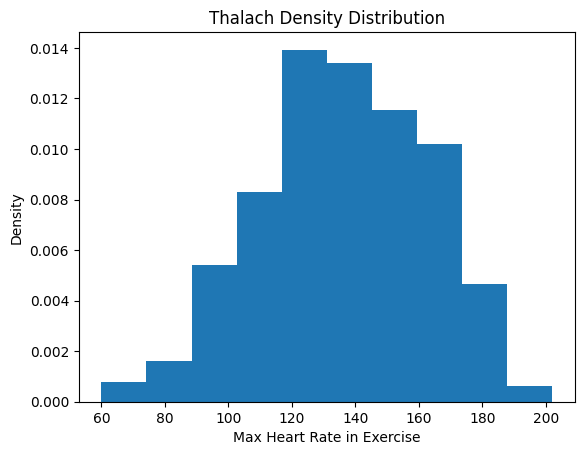

In [72]:
print(f"Thalach Mean: {df['thalach'].mean()}, Thalach Std: {df['thalach'].std()}")
plt.hist(df["thalach"], density=True)
plt.title("Thalach Density Distribution")
plt.xlabel("Max Heart Rate in Exercise")
plt.ylabel("Density")

### Resting ECG

The counts of resting ecg show that most people have normal ECGs and there is an equal amount of the two abnormalities.

Text(0.5, 1.0, 'Resting ECG')

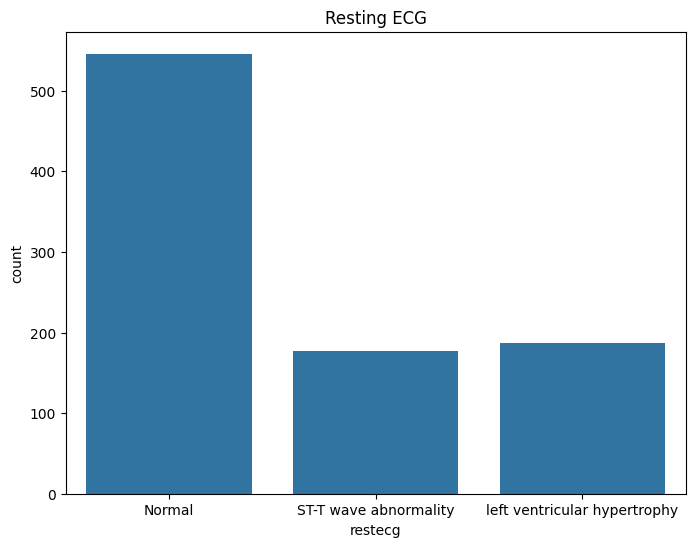

In [73]:
plt.figure(figsize=(8,6))
sns.countplot(x=df['restecg'])
plt.xticks(ticks=range(len(df['restecg'].unique())), labels=['Normal', 'ST-T wave abnormality', 'left ventricular hypertrophy'])
plt.title("Resting ECG")

### Fasting Blood Sugar

The fasting blood pressure column indicates if a person has a blood pressure above (1) or below (0) 120 mg/dL

Text(0.5, 1.0, 'Bar Graph of Fasting Blood Sugar Classification')

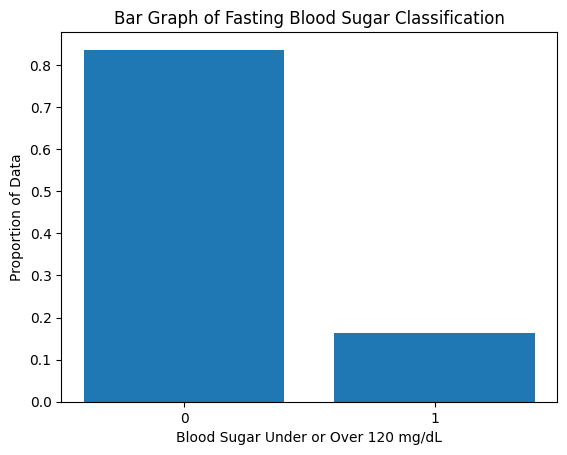

In [74]:
fbs_vals = df["fbs"].value_counts(normalize=True)
plt.bar(fbs_vals.index, fbs_vals.values)
plt.xticks([0, 1])
plt.xlabel("Blood Sugar Under or Over 120 mg/dL")
plt.ylabel("Proportion of Data")
plt.title("Bar Graph of Fasting Blood Sugar Classification")

## Cholesterol Analysis

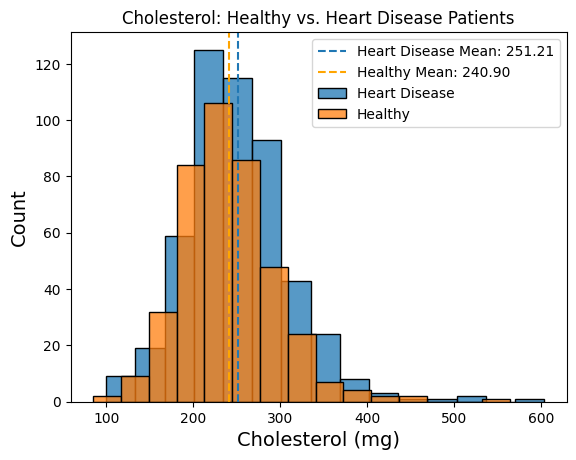

In [ ]:
# split dataframe into only heart disease patients and only healthy patients
heart_dis = df[df['num'] > 0]
healthy = df[df['num'] == 0]

# find mean cholesterol for each group
mean_heart_dis_chol = heart_dis['chol'].mean()
mean_healthy_chol = healthy['chol'].mean()
# plot cholesterol distributions in histogram
sns.histplot(heart_dis['chol'], bins=15, label='Heart Disease')
sns.histplot(healthy['chol'], bins=15, label='Healthy')
# add dashed line at mean for heart disease and healthy patients
plt.axvline(mean_heart_dis_chol, linestyle='dashed', label=f'Heart Disease Mean: {mean_heart_dis_chol:.2f}')
plt.axvline(mean_healthy_chol, linestyle='dashed', color='orange', label=f'Healthy Mean: {mean_healthy_chol:.2f}')
# add labels and title
plt.xlabel('Cholesterol (mg)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Cholesterol: Healthy vs. Heart Disease Patients')
plt.legend()
plt.show()

The distribution for cholesterol levels between heart disease and healthy patients shows that heart disease patients have a higher average cholesterol than healthy patients.

In [ ]:
# perform t-test for cholesterol between heart disease and healthy patients
t_stat_chol, p_value_chol = ttest_ind(healthy['chol'], heart_dis['chol'])
print("T-Test for Cholesterol (Healthy vs. Heart Disease Patients):")
print(f"T-statistic: {t_stat_chol}")
print(f"P-value: {p_value_chol}")

T-Test for Cholesterol (Healthy vs. Heart Disease Patients):
T-statistic: -2.635447985767705
P-value: 0.008545893073588468


From performing a t-test on the cholesterol between heart disease and healthy patients, we find that there is a significant difference between the two groups as the p-value is <0.01. We can conclude that heart disease patients have a significantly higher cholesterol than healthy patients. This suggests that high cholesterol is an indication of presence of heart disease. 

#### Difference Between Sexes

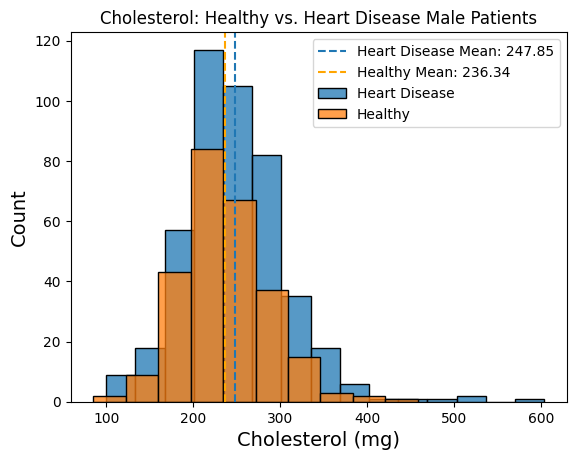

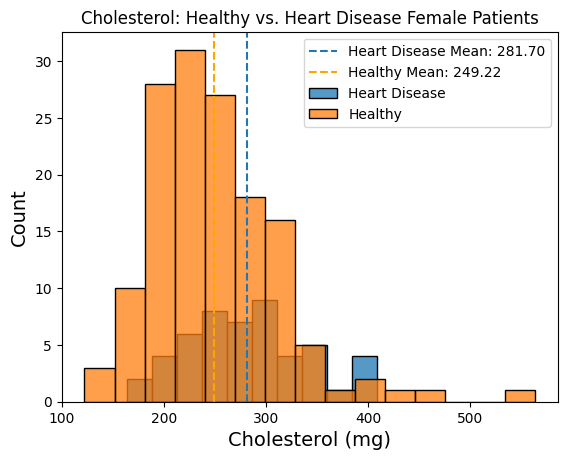

In [ ]:
# make dataframes for heart disease and healthy patients with only male patients
male_df = df[df['sex'] == 'Man']
m_heart_dis = male_df[male_df['num'] > 0]
m_healthy = male_df[male_df['num'] == 0]

# make dataframes for heart disease and healthy patients with only female patients
female_df = df[df['sex'] == 'Woman']
f_heart_dis = female_df[female_df['num'] > 0]
f_healthy = female_df[female_df['num'] == 0]

# find mean cholesterol for each group for male patients
m_mean_heart_dis_chol = m_heart_dis['chol'].mean()
m_mean_healthy_chol = m_healthy['chol'].mean()
# plot cholesterol distributions for male patients in histogram
sns.histplot(m_heart_dis['chol'], bins=15, label='Heart Disease')
sns.histplot(m_healthy['chol'], bins=10, label='Healthy')
# add dashed line at mean for heart disease and healthy patients
plt.axvline(m_mean_heart_dis_chol, linestyle='dashed', label=f'Heart Disease Mean: {m_mean_heart_dis_chol:.2f}')
plt.axvline(m_mean_healthy_chol, linestyle='dashed', color='orange', label=f'Healthy Mean: {m_mean_healthy_chol:.2f}')
# add labels and title
plt.xlabel('Cholesterol (mg)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Cholesterol: Healthy vs. Heart Disease Male Patients')
plt.legend()
plt.show()

# find mean cholesterol for each group for female patients
f_mean_heart_dis_chol = f_heart_dis['chol'].mean()
f_mean_healthy_chol = f_healthy['chol'].mean()
# plot cholesterol distributions for female patients in histogram
sns.histplot(f_heart_dis['chol'], bins=10, label='Heart Disease')
sns.histplot(f_healthy['chol'], bins=15, label='Healthy')
# add dashed line at mean for heart disease and healthy patients
plt.axvline(f_mean_heart_dis_chol, linestyle='dashed', label=f'Heart Disease Mean: {f_mean_heart_dis_chol:.2f}')
plt.axvline(f_mean_healthy_chol, linestyle='dashed', color='orange', label=f'Healthy Mean: {f_mean_healthy_chol:.2f}')
# add labels and title
plt.xlabel('Cholesterol (mg)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Cholesterol: Healthy vs. Heart Disease Female Patients')
plt.legend()
plt.show()

The distribution of cholesterol between heart disease and healthy patients for men and women also both show the same relationship with heart disease patients having a higher average cholesterol than healthy patients.

In [ ]:
# perform t-test for cholesterol between heart disease and healthy patients in male patients
m_t_stat_chol, m_p_value_chol = ttest_ind(m_healthy['chol'], m_heart_dis['chol'])
print("T-Test for Cholesterol (Healthy vs. Heart Disease Patients) in Men:")
print(f"T-statistic: {m_t_stat_chol}")
print(f"P-value: {m_p_value_chol}")
print('\n')

# perform t-test for cholesterol between heart disease and healthy patients in female patients
f_t_stat_chol, f_p_value_chol = ttest_ind(f_healthy['chol'], f_heart_dis['chol'])
print("T-Test for Cholesterol (Healthy vs. Heart Disease Patients) in Women:")
print(f"T-statistic: {f_t_stat_chol}")
print(f"P-value: {f_p_value_chol}")

T-Test for Cholesterol (Healthy vs. Heart Disease Patients) in Men:
T-statistic: -2.602168038402623
P-value: 0.009455735937984117


T-Test for Cholesterol (Healthy vs. Heart Disease Patients) in Women:
T-statistic: -3.1906789553929342
P-value: 0.001658165355525721


T-tests for both men and women also have a small p-value (<0.01) that suggests a significant relationship between cholesterol and heart disease with high cholesterol indicating presence of heart disease for both sexes.

## Resting Blood Pressure Analysis

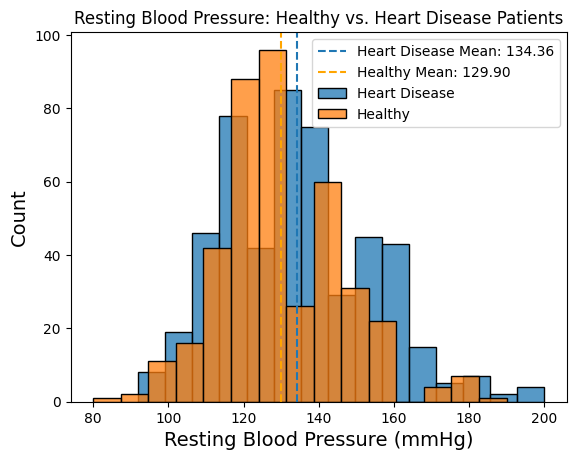

In [ ]:
# find mean resting blood pressure for each group
mean_heart_dis_trestbps = heart_dis['trestbps'].mean()
mean_healthy_trestbps = healthy['trestbps'].mean()
# plot resting blood pressure distribution in histogram
sns.histplot(heart_dis['trestbps'], bins=15, label='Heart Disease')
sns.histplot(healthy['trestbps'], bins=15, label='Healthy')
# add dashed line at mean for heart disease and healthy patients
plt.axvline(mean_heart_dis_trestbps, linestyle='dashed', label=f'Heart Disease Mean: {mean_heart_dis_trestbps:.2f}')
plt.axvline(mean_healthy_trestbps, linestyle='dashed', color='orange', label=f'Healthy Mean: {mean_healthy_trestbps:.2f}')
# add labels and title
plt.xlabel('Resting Blood Pressure (mmHg)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Resting Blood Pressure: Healthy vs. Heart Disease Patients')
plt.legend()
plt.show()

The distribution of resting blood pressures between heart disease and healthy patients shows that heart disease patients have a higher average resting blood pressure.

In [ ]:
# perform t-test for resting blood pressure between heart disease and healthy patients
t_stat_trestbps, p_value_trestbps = ttest_ind(healthy['trestbps'], heart_dis['trestbps'])
print("T-Test for Resting Blood Pressure (Healthy vs. Heart Disease Patients):")
print(f"T-statistic: {t_stat_trestbps}")
print(f"P-value: {p_value_trestbps}")

T-Test for Resting Blood Pressure (Healthy vs. Heart Disease Patients):
T-statistic: -3.6244942130123463
P-value: 0.0003056153987209096


Using a t-test to compare the blood pressure between healthy and heart disease patients, we achieved a small p-value of <0.01 meaning there is a statistically significant difference between the blood pressures with the heart disease patients having significantly higher resting blood pressure than healthy patients. This suggests that there is an association between blood pressure and heart disease, and a higher resting blood pressure may indicate higher risk for presence of heart disease.

#### Difference Between Sexes

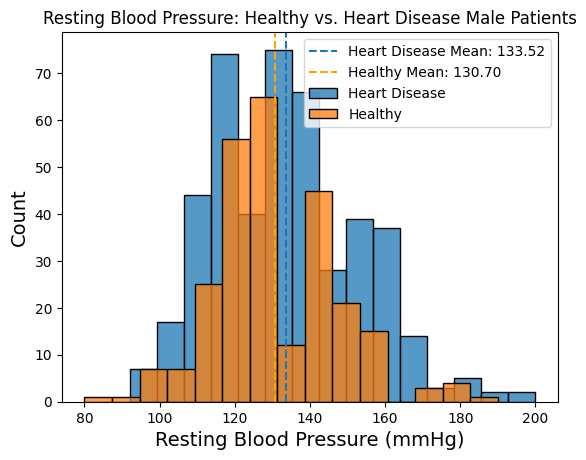

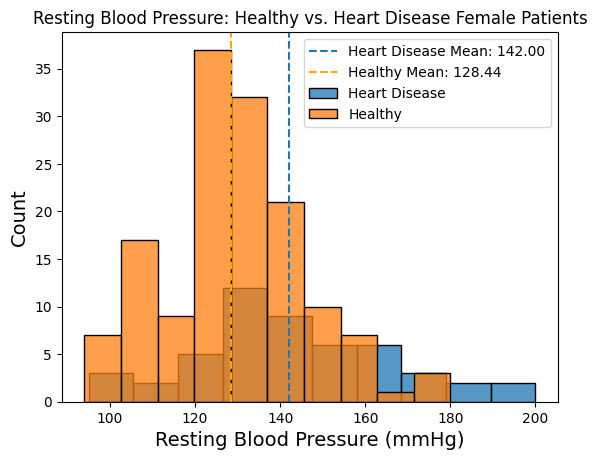

In [ ]:
# find mean cholesterol for each group for male patients
m_mean_heart_dis_trest = m_heart_dis['trestbps'].mean()
m_mean_healthy_trest = m_healthy['trestbps'].mean()
# plot resting blood pressure distributions for male patients in histogram
sns.histplot(m_heart_dis['trestbps'], bins=15, label='Heart Disease')
sns.histplot(m_healthy['trestbps'], bins=15, label='Healthy')
# add dashed line at mean for heart disease and healthy patients
plt.axvline(m_mean_heart_dis_trest, linestyle='dashed', label=f'Heart Disease Mean: {m_mean_heart_dis_trest:.2f}')
plt.axvline(m_mean_healthy_trest, linestyle='dashed', color='orange', label=f'Healthy Mean: {m_mean_healthy_trest:.2f}')
# add labels and title
plt.xlabel('Resting Blood Pressure (mmHg)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Resting Blood Pressure: Healthy vs. Heart Disease Male Patients')
plt.legend()
plt.show()

# find mean resting blood pressure for each group for female patients
f_mean_heart_dis_trest = f_heart_dis['trestbps'].mean()
f_mean_healthy_trest = f_healthy['trestbps'].mean()
# plot resting blood sugar distributions for female patients in histogram
sns.histplot(f_heart_dis['trestbps'], bins=10, label='Heart Disease')
sns.histplot(f_healthy['trestbps'], bins=10, label='Healthy')
# add dashed line at mean for heart disease and healthy patients
plt.axvline(f_mean_heart_dis_trest, linestyle='dashed', label=f'Heart Disease Mean: {f_mean_heart_dis_trest:.2f}')
plt.axvline(f_mean_healthy_trest, linestyle='dashed', color='orange', label=f'Healthy Mean: {f_mean_healthy_trest:.2f}')
# add labels and title
plt.xlabel('Resting Blood Pressure (mmHg)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Resting Blood Pressure: Healthy vs. Heart Disease Female Patients')
plt.legend()
plt.show()


The distributions of resting blood pressure in only male or female patients also show the same relationship in both groups with heart disease patients having a higher average blood pressure than healthy patients.

In [ ]:
# perform t-test for resting blood pressure between heart disease and healthy patients in male patients
m_t_stat_trestbps, m_p_value_trestbps = ttest_ind(m_healthy['trestbps'], m_heart_dis['trestbps'])
print("T-Test for Resting Blood Pressure (Healthy vs. Heart Disease Patients) in Men:")
print(f"T-statistic: {m_t_stat_trestbps}")
print(f"P-value: {m_p_value_trestbps}")
print('\n')

# perform t-test for resting blood pressure between heart disease and healthy patients in female patients
f_t_stat_trestbps, f_p_value_trestbps = ttest_ind(f_healthy['trestbps'], f_heart_dis['trestbps'])
print("T-Test for Resting Blood Pressure (Healthy vs. Heart Disease Patients) in Women:")
print(f"T-statistic: {f_t_stat_trestbps}")
print(f"P-value: {f_p_value_trestbps}")

T-Test for Resting Blood Pressure (Healthy vs. Heart Disease Patients) in Men:
T-statistic: -1.9890792683990783
P-value: 0.047073648184797076


T-Test for Resting Blood Pressure (Healthy vs. Heart Disease Patients) in Women:
T-statistic: -4.416708962643842
P-value: 1.6718054431029743e-05


From performing a t-test on the blood pressures between heart disease and healthy patients for men and women independently, we find that both groups also have small p-values that show a significant relationship between blood pressure and heart disease. In women, the p-value is extremely significant (<0.01) while it is only moderately significant (<0.05) for men. This suggests that there may be a more significant indication of heart disease from high blood pressure in women.

## Max Heart Rate Analysis

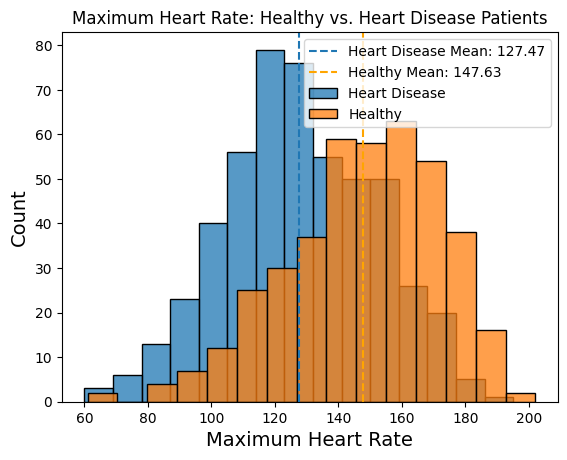

In [ ]:
# find mean max heart rate for each group
mean_heart_dis_thalach = heart_dis['thalach'].mean()
mean_healthy_thalach = healthy['thalach'].mean()
# plot max heart rate distributions in histogram
sns.histplot(heart_dis['thalach'], bins=15, label='Heart Disease')
sns.histplot(healthy['thalach'], bins=15, label='Healthy')
# add dashed line at mean for heart disease and healthy patients
plt.axvline(mean_heart_dis_thalach, linestyle='dashed', label=f'Heart Disease Mean: {mean_heart_dis_thalach:.2f}')
plt.axvline(mean_healthy_thalach, linestyle='dashed', color='orange', label=f'Healthy Mean: {mean_healthy_thalach:.2f}')
# add labels and title
plt.xlabel('Maximum Heart Rate', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Maximum Heart Rate: Healthy vs. Heart Disease Patients')
plt.legend()
plt.show()

The distribution of max heart rate shows that heart disease patients have a lower average max heart rate compared to healthy patients.

In [ ]:
# perform t-test for max heart rate between heart disease and healthy patients
t_stat_thalach, p_value_thalach = ttest_ind(healthy['thalach'], heart_dis['thalach'])
print("T-Test for Maximum Heart Rate (Healthy vs. Heart Disease Patients):")
print(f"T-statistic: {t_stat_thalach}")
print(f"P-value: {p_value_thalach}")

T-Test for Maximum Heart Rate (Healthy vs. Heart Disease Patients):
T-statistic: 12.595128171559335
P-value: 1.2169282187065136e-33


The t-test resulted in a very small p-value (<0.01) confirming that there is a significant difference between the max heart rate of healthy and heart disease patients. Heart disease patients have significantly lower max heart rate which suggests low max heart rate may indicate presence of heart disease.

#### Difference Between Sexes

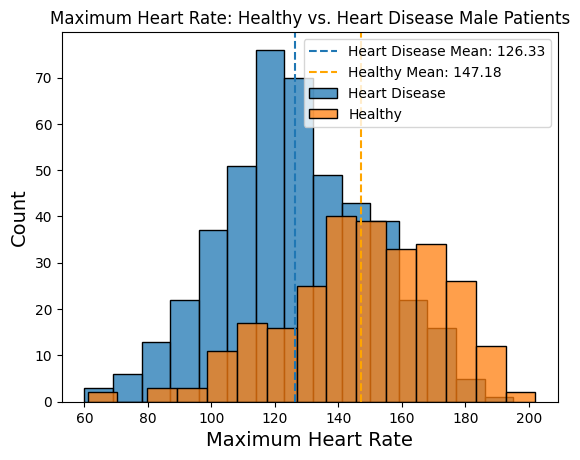

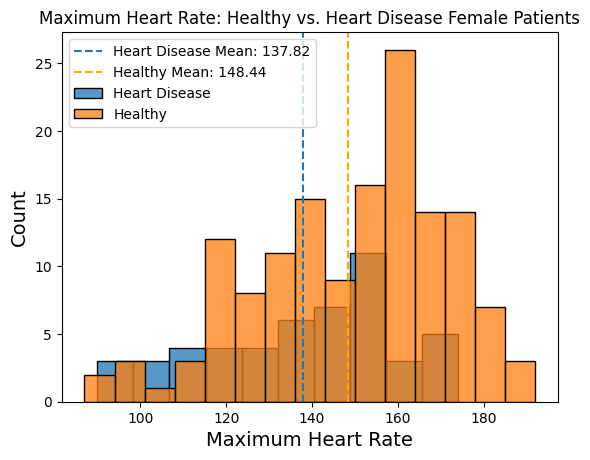

In [ ]:
# find mean max heart rate for each group for male patients
m_mean_heart_dis_thal = m_heart_dis['thalach'].mean()
m_mean_healthy_thal = m_healthy['thalach'].mean()
# plot max heart rate distributions for male patients in histogram
sns.histplot(m_heart_dis['thalach'], bins=15, label='Heart Disease')
sns.histplot(m_healthy['thalach'], bins=15, label='Healthy')
# add dashed line at mean for heart disease and healthy patients
plt.axvline(m_mean_heart_dis_thal, linestyle='dashed', label=f'Heart Disease Mean: {m_mean_heart_dis_thal:.2f}')
plt.axvline(m_mean_healthy_thal, linestyle='dashed', color='orange', label=f'Healthy Mean: {m_mean_healthy_thal:.2f}')
# add labels and title
plt.xlabel('Maximum Heart Rate', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Maximum Heart Rate: Healthy vs. Heart Disease Male Patients')
plt.legend()
plt.show()

# find mean max heart rate for each group for female patients
f_mean_heart_dis_thal = f_heart_dis['thalach'].mean()
f_mean_healthy_thal = f_healthy['thalach'].mean()
# plot max heart rate distributions for female patients in histogram
sns.histplot(f_heart_dis['thalach'], bins=10, label='Heart Disease')
sns.histplot(f_healthy['thalach'], bins=15, label='Healthy')
# add dashed line at mean for heart disease and healthy patients
plt.axvline(f_mean_heart_dis_thal, linestyle='dashed', label=f'Heart Disease Mean: {f_mean_heart_dis_thal:.2f}')
plt.axvline(f_mean_healthy_thal, linestyle='dashed', color='orange', label=f'Healthy Mean: {f_mean_healthy_thal:.2f}')
# add labels and title
plt.xlabel('Maximum Heart Rate', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Maximum Heart Rate: Healthy vs. Heart Disease Female Patients')
plt.legend()
plt.show()

From analyzing the max heart rate distribution in men and women, we see that both sexes also show that heart disease patients have a lower average maximum heart rate compared to healthy patients. 

In [ ]:
# perform t-test for max heart rate between heart disease and healthy patients in male patients
m_t_stat_thal, m_p_value_thal = ttest_ind(m_healthy['thalach'], m_heart_dis['thalach'])
print("T-Test for Maximum Heart Rate (Healthy vs. Heart Disease Patients) in Men:")
print(f"T-statistic: {m_t_stat_thal}")
print(f"P-value: {m_p_value_thal}")
print('\n')

# perform t-test for max heart rate between heart disease and healthy patients in female patients
f_t_stat_thal, f_p_value_thal = ttest_ind(f_healthy['thalach'], f_heart_dis['thalach'])
print("T-Test for Maximum Heart Rate (Healthy vs. Heart Disease Patients) in Women:")
print(f"T-statistic: {f_t_stat_thal}")
print(f"P-value: {f_p_value_thal}")

T-Test for Maximum Heart Rate (Healthy vs. Heart Disease Patients) in Men:
T-statistic: 11.06796395005068
P-value: 2.1806657546386697e-26


T-Test for Maximum Heart Rate (Healthy vs. Heart Disease Patients) in Women:
T-statistic: 2.9039045166298774
P-value: 0.004117305394963418


The t-test for men and women also both show a small p-value (<0.01) that indicates a significant difference in heart rate between heart disease and healthy patients. We can conclude that a lower heart rate is associated with the presence of heart disease in both sexes.

## Resting ECG Analysis

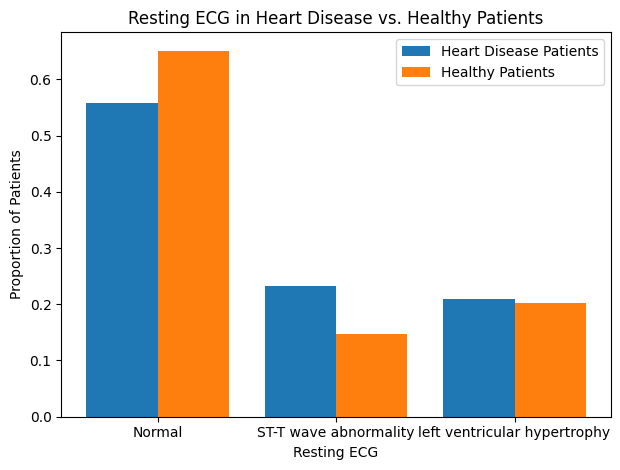

In [ ]:
# get counts of each resting ecg category for heart disease and healthy patients
heart_dis_counts_restecg = heart_dis['restecg'].value_counts().sort_index()
healthy_counts_restecg = healthy['restecg'].value_counts().sort_index()
# calculate proportions of each resting ecg catergory using counts
heart_dis_prop_restecg = heart_dis_counts_restecg / len(heart_dis)
healthy_prop_restecg = healthy_counts_restecg / len(healthy)
# plot proportions in bar graph
x=range(len(heart_dis_counts_restecg))
plt.bar(x, heart_dis_prop_restecg, width=0.4, label='Heart Disease Patients')
plt.bar([p + 0.4 for p in x], healthy_prop_restecg, width=0.4, label='Healthy Patients')
# add labels and title
plt.xticks([p + 0.2 for p in x], ['Normal','ST-T wave abnormality','left ventricular hypertrophy'])
plt.xlabel('Resting ECG')
plt.ylabel('Proportion of Patients')
plt.title('Resting ECG in Heart Disease vs. Healthy Patients')
plt.legend()
plt.tight_layout()
plt.show()

Here we show that for both ECG abnormalities reported, there was a higher proportion of patients who had an abnormality in heart disease patients compared to healthy patients, and healthy patients had a higher proportion of normal ECGs.

In [ ]:
# perform chi-square test for resting ecg between heart disease and healthy patients
contingency_table_restecg = pd.DataFrame({'Heart Disease': heart_dis_counts_restecg,'Healthy': healthy_counts_restecg})
chi2_stat_restecg, p_value_restecg, dof_restecg, expected_restecg = stats.chi2_contingency(contingency_table_restecg)
print("Chi-square statistic:", chi2_stat_restecg)
print("p-value:", p_value_restecg)

Chi-square statistic: 11.655920951468259
p-value: 0.0029440753743756537


The small p-value (<0.01) from performing a chi-square test indicates that there is a statistically significant difference between the distribution of normal vs abnormal ECGs between heart disease and healthy patients. Specifically, heart disease patients have significantly more abnormalities in their ECGs. This suggests there is an association between ECG abnormalities and the presence of heart disease and having an ECG abnormality may indicate higher risk of heart disease.

#### Difference Between Sexes

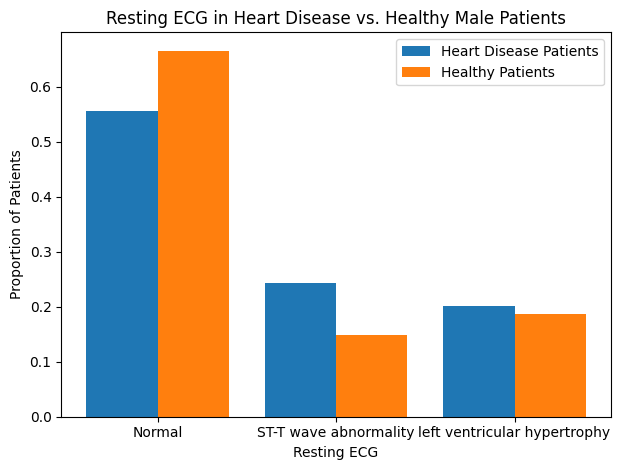

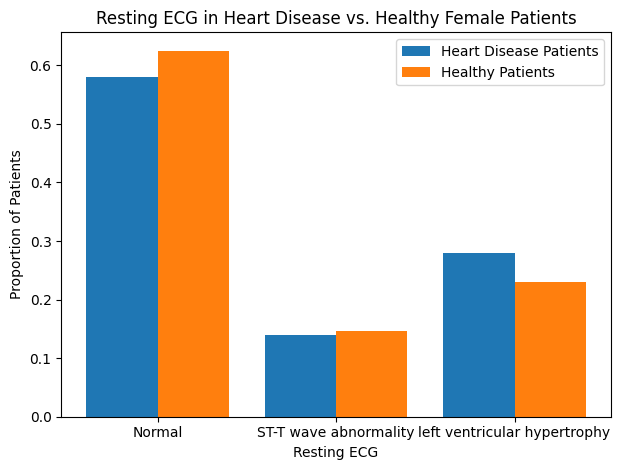

In [ ]:
# get counts of each resting ecg category for heart disease and healthy patients in male patients
m_heart_dis_counts_restecg = m_heart_dis['restecg'].value_counts().sort_index()
m_healthy_counts_restecg = m_healthy['restecg'].value_counts().sort_index()
# calculate proportions of each resting ecg catergory using counts for male patients
m_heart_dis_prop_restecg = m_heart_dis_counts_restecg / len(m_heart_dis)
m_healthy_prop_restecg = m_healthy_counts_restecg / len(m_healthy)
# plot proportions in bar graph
x=range(len(m_heart_dis_counts_restecg))
plt.bar(x, m_heart_dis_prop_restecg, width=0.4, label='Heart Disease Patients')
plt.bar([p + 0.4 for p in x], m_healthy_prop_restecg, width=0.4, label='Healthy Patients')
# add labels and title
plt.xticks([p + 0.2 for p in x], ['Normal','ST-T wave abnormality','left ventricular hypertrophy'])
plt.xlabel('Resting ECG')
plt.ylabel('Proportion of Patients')
plt.title('Resting ECG in Heart Disease vs. Healthy Male Patients')
plt.legend()
plt.tight_layout()
plt.show()

# get counts of each resting ecg category for heart disease and healthy patients in female patients
f_heart_dis_counts_restecg = f_heart_dis['restecg'].value_counts().sort_index()
f_healthy_counts_restecg = f_healthy['restecg'].value_counts().sort_index()
# calculate proportions of each resting ecg catergory using counts for female patients
f_heart_dis_prop_restecg = f_heart_dis_counts_restecg / len(f_heart_dis)
f_healthy_prop_restecg = f_healthy_counts_restecg / len(f_healthy)
# plot proportions in bar graph
x=range(len(f_heart_dis_counts_restecg))
plt.bar(x, f_heart_dis_prop_restecg, width=0.4, label='Heart Disease Patients')
plt.bar([p + 0.4 for p in x], f_healthy_prop_restecg, width=0.4, label='Healthy Patients')
# add labels and title
plt.xticks([p + 0.2 for p in x], ['Normal','ST-T wave abnormality','left ventricular hypertrophy'])
plt.xlabel('Resting ECG')
plt.ylabel('Proportion of Patients')
plt.title('Resting ECG in Heart Disease vs. Healthy Female Patients')
plt.legend()
plt.tight_layout()
plt.show()

When looking at proportions of patients with ECG abnormalities within only male or female patients, both groups show a similar trend with higher proportions of abnormalities in heart disease patients and higher proportion of normal ECGs in healthy patients. Although, notably, the proportion of ST-T wave abnormality is actually slightly higher in healthy patients than heart disease patients for the female group.

In [ ]:
# perform chi-square for resting ecg between heart disease and healthy patients in male patients
m_contingency_table_restecg = pd.DataFrame({'Heart Disease': m_heart_dis_counts_restecg,'Healthy': m_healthy_counts_restecg})
m_chi2_stat_restecg, m_p_value_restecg, m_dof_restecg, m_expected_restecg = stats.chi2_contingency(m_contingency_table_restecg)
print("Male Patients:")
print("Chi-square statistic:", m_chi2_stat_restecg)
print("p-value:", m_p_value_restecg)
print("\n")

# perform chi-square for resting ecg between heart disease and healthy patients in female patients
f_contingency_table_restecg = pd.DataFrame({'Heart Disease': f_heart_dis_counts_restecg,'Healthy': f_healthy_counts_restecg})
f_chi2_stat_restecg, f_p_value_restecg, f_dof_restecg, f_expected_restecg = stats.chi2_contingency(f_contingency_table_restecg)
print("Female Patients:")
print("Chi-square statistic:", f_chi2_stat_restecg)
print("p-value:", f_p_value_restecg)

Male Patients:
Chi-square statistic: 10.648293412669801
p-value: 0.004872506920161624


Female Patients:
Chi-square statistic: 0.5271220722331486
p-value: 0.7683107263050081


The p-value after performing a chi-square test for the male patients is very small (<0.01) which shows that the difference in distribution of ECG abnormalities is statistitically signifcant for this group. However, for the female patients, there is a large p-value, meaning there is no significant difference between the ECG abnormality proportions between heart disease and healthy patients. This result suggests that ECG abnormality is only an indicator of heart disease in male patients and not female patients.

## Fasting Blood Sugar Analysis

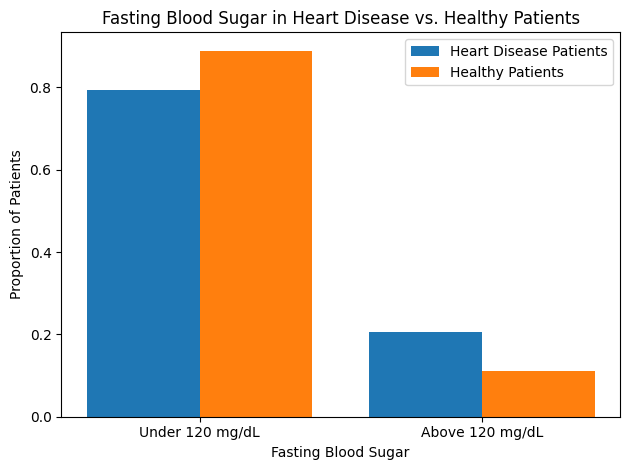

In [ ]:
# get counts of each fasting blood sugar category for heart disease and healthy patients
heart_dis_counts_fbs = heart_dis['fbs'].value_counts().sort_index()
healthy_counts_fbs = healthy['fbs'].value_counts().sort_index()
# calculate proportions of each fasting blood sugar catergory using counts
heart_dis_prop_fbs = heart_dis_counts_fbs / len(heart_dis)
healthy_prop_fbs = healthy_counts_fbs / len(healthy)
# plot proportions in bar graph
x=range(len(heart_dis_counts_fbs))
plt.bar(x, heart_dis_prop_fbs, width=0.4, label='Heart Disease Patients')
plt.bar([p + 0.4 for p in x], healthy_prop_fbs, width=0.4, label='Healthy Patients')
# add labels and titles
plt.xticks([p + 0.2 for p in x], ['Under 120 mg/dL', 'Above 120 mg/dL'])
plt.xlabel('Fasting Blood Sugar')
plt.ylabel('Proportion of Patients')
plt.title('Fasting Blood Sugar in Heart Disease vs. Healthy Patients')
plt.legend()
plt.tight_layout()
plt.show()

We find that heart disease patients have a higher proportion of blood sugar above 120 mg/dL while healthy patients have a higher proportion of lower blood sugar.

In [ ]:
# perform chi-square test for fasting blood sugar between heart disease and healthy patients
contingency_table_fbs = pd.DataFrame({'Heart Disease': heart_dis_counts_fbs,'Healthy': healthy_counts_fbs})
chi2_stat_fbs, p_value_fbs, dof_fbs, expected_fbs = stats.chi2_contingency(contingency_table_fbs)
print("Chi-square statistic:", chi2_stat_fbs)
print("p-value:", p_value_fbs)

Chi-square statistic: 14.508680385528232
p-value: 0.00013951519085425384


By performing a chi-square test, we achieve a small p-value of <0.01 meaning there is statistically significant difference in the distribution of fasting blood sugar between heart disease and healthy patients. Heart disease patients have a significantly higher proportion of patients with high blood sugar. This suggests that high blood sugar may be an indication of heart disease.

#### Difference Between Sexes

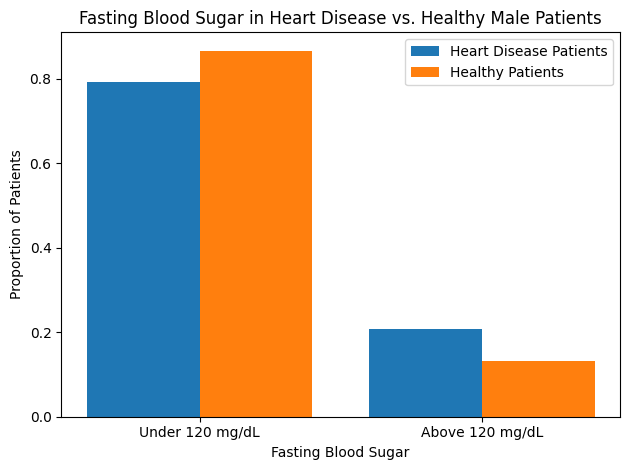

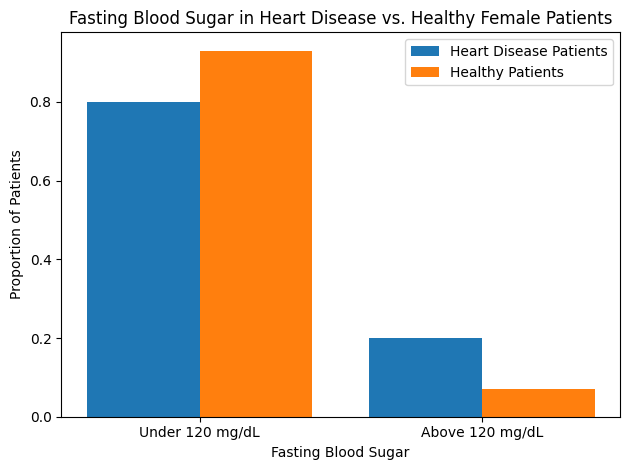

In [ ]:
# get counts of each fasting blood sugar category for heart disease and healthy patients in male patients
m_heart_dis_counts_fbs = m_heart_dis['fbs'].value_counts().sort_index()
m_healthy_counts_fbs = m_healthy['fbs'].value_counts().sort_index()
# calculate proportions of each fasting blood sugar catergory using counts for male patients
m_heart_dis_prop_fbs = m_heart_dis_counts_fbs / len(m_heart_dis)
m_healthy_prop_fbs = m_healthy_counts_fbs / len(m_healthy)
# plot proportions in bar graph
x=range(len(m_heart_dis_counts_fbs))
plt.bar(x, m_heart_dis_prop_fbs, width=0.4, label='Heart Disease Patients')
plt.bar([p + 0.4 for p in x], m_healthy_prop_fbs, width=0.4, label='Healthy Patients')
# add labels and title
plt.xticks([p + 0.2 for p in x], ['Under 120 mg/dL', 'Above 120 mg/dL'])
plt.xlabel('Fasting Blood Sugar')
plt.ylabel('Proportion of Patients')
plt.title('Fasting Blood Sugar in Heart Disease vs. Healthy Male Patients')
plt.legend()
plt.tight_layout()
plt.show()

# get counts of each fasting blood sugar category for heart disease and healthy patients in female patients
f_heart_dis_counts_fbs = f_heart_dis['fbs'].value_counts().sort_index()
f_healthy_counts_fbs = f_healthy['fbs'].value_counts().sort_index()
# calculate proportions of each fasting blood sugar catergory using counts for female patients
f_heart_dis_prop_fbs = f_heart_dis_counts_fbs / len(f_heart_dis)
f_healthy_prop_fbs = f_healthy_counts_fbs / len(f_healthy)
# plot proportions in bar graph
x=range(len(f_heart_dis_counts_fbs))
plt.bar(x, f_heart_dis_prop_fbs, width=0.4, label='Heart Disease Patients')
plt.bar([p + 0.4 for p in x], f_healthy_prop_fbs, width=0.4, label='Healthy Patients')
# add labels and title
plt.xticks([p + 0.2 for p in x], ['Under 120 mg/dL', 'Above 120 mg/dL'])
plt.xlabel('Fasting Blood Sugar')
plt.ylabel('Proportion of Patients')
plt.title('Fasting Blood Sugar in Heart Disease vs. Healthy Female Patients')
plt.legend()
plt.tight_layout()
plt.show()

In both men and women, we find the same relationship with heart disease patients having a higher proportion of patients with high blood sugar and healthy pateints having a higher proportion of patients with lower blood sugar.

In [ ]:
# perform chi-square for fasting blood sugar between heart disease and healthy patients in male patients
m_contingency_table_fbs = pd.DataFrame({'Heart Disease': m_heart_dis_counts_fbs,'Healthy': m_healthy_counts_fbs})
m_chi2_stat_fbs, m_p_value_fbs, m_dof_fbs, m_expected_fbs = stats.chi2_contingency(m_contingency_table_fbs)
print("Male Patients:")
print("Chi-square statistic:", m_chi2_stat_fbs)
print("p-value:", m_p_value_fbs)
print("\n")

# perform chi-square for fasting blood sugar between heart disease and healthy patients in female patients
f_contingency_table_fbs = pd.DataFrame({'Heart Disease': f_heart_dis_counts_fbs,'Healthy': f_healthy_counts_fbs})
f_chi2_stat_fbs, f_p_value_fbs, f_dof_fbs, f_expected_fbs = stats.chi2_contingency(f_contingency_table_fbs)
print("Female Patients:")
print("Chi-square statistic:", f_chi2_stat_fbs)
print("p-value:", f_p_value_fbs)

Male Patients:
Chi-square statistic: 5.746300157344018
p-value: 0.016523421103038418


Female Patients:
Chi-square statistic: 5.502311063218389
p-value: 0.018991358612348998


The chi-square test for both men and women also both resulted in a significant p-value of <0.05 which shows there is a significant difference in the proportion of patients with high or low blood sugar between the heart disease and healthy patients. Thus, we conclude that for both men and women, high blood sugar is an indication of heart disease.

# Ethics & Privacy

Our research investigates how biometric factors, such as cholesterol, heart rate, and blood sugar, contribute to heart disease risk. While this study can provide invaluable insights into people’s health, it also raises critical ethical, privacy, and bias concerns. We acknowledge that no single metric is completely “fair” across all demographics, and that heart disease risk can vary significantly among different groups. As a result, any measure of fairness must be chosen and applied with great care to avoid misrepresenting certain populations. For example, If the data sets we use underrepresent specific groups or individuals with limited access to healthcare, our analyses may produce misleading conclusions. Likewise, disparities in medical treatment may not be reflected in the data, causing a potential skew in outcomes. To mitigate these issues, we will scrutinize the data for missing or unbalanced information, and carefully examine the metrics we use for biases. Even so, it is impossible to have complete perfect fairness so we will maintain clarity when analyzing data that may skew from our standard for unbiased data and we will convey when conclusions are drawn from possible biased data. 
Privacy is equally important, given the sensitive nature of health data. We understand that removing direct identifiers, such as names, does not guarantee anonymity, as individuals can still sometimes be re-identified based on rare conditions or demographic details. To address this concern, we will follow established best practices for privatizing peoples’ information by employing rigorous protocols to obscure any potentially identifying information (zipcodes, birthdates, unusual medical conditions, etc). We will also analyze filtered/manipulated data to ensure that re-identification is highly unlikely. Moreover, we will only use datasets in which patients have consented to release their information for research purposes or datasets that are publicly available with appropriate legal and ethical clearances. We will also be transparent about any limitations in anonymization.
To reaffirm, our top priority is to analyze data while maximizing privacy and ensuring clarity in how we use and manipulate the data. We realize fairness and privacy metrics are imperfect but we retain that we will put the ethics and safety of people above our study.

# Discusison and Conclusion

We investigated what biometric factors (such as cholesterol, heart rate, and blood sugar) contribute to the risk of heart disease and how these factors differ between sexes. We now believe that if an individual has higher cholesterol, blood sugar, or heart rate, then they are at a higher risk of having heart disease. We attribute poor overall health to weak cardiovascular health. We also believe each factor may affect men's and women’s chances of contracting health disease differently due to genetic and biological differences. After performing multiple rounds of analysis we found evidence that both supports and contradicts our hypothesis. We also used p = 0.05 as our significance level. 

First, we hypothesized individuals with higher cholesterol are more prone to heart disease. According to our analysis, we have statistically significant evidence that supports a correlation between high cholesterol and heart disease. Specifically, our t-test yielded a P-value below 0.01, indicating a strong statistical association between the two variables. Additionally, while there was a greater population of men than women in this analysis, there was not a significant difference between genders in correlation to heart disease.
The next health factor analyzed was blood pressure. We saw that we had statistically significant evidence that there was a difference in resting blood pressure in those with and without heart disease (p = 0.003). Additionally, we saw that this difference within men (p = 0.047) and women (p = 1.67e-5) persisted. With this data, we concluded that higher blood pressure plays a major factor in contributing to heart disease. 

Next, we analyzed the relationship between maximum heart rate and heart disease. We originally hypothesized that the presence of heart disease would correlate with a higher maximum heart rate. While our t-test and graphs do show that there is a statistically significant difference between the heart rate of healthy people and the heart rate of people with heart disease, the statistical significance is in the opposite direction. Healthy people tended to have a faster max heart rate than people with heart disease by a margin of about 20 beats per second. This could mean that people with heart disease have a weaker heart, preventing their body from pushing it to a higher beat per minute. We found this relationship was the same for both men and women.

With resting ECG, we had to perform a chi-square test due to the data being categorical. The three categories are “Normal”, “Left Ventricle ST-T Wave Abnormality”, and “Left Ventricle Hypertrophy”. When doing this between heart disease groups, we saw statistically significant results (p = 0.003), indicating there is a difference between the two heart disease groups across the three categorical values. People with heart disease had a higher proportion of ECG abnormalities. We also saw similar results for the men subgroup (p = 0.005). However, this difference was not apparent in the women subgroup (p = 0.768). This indicates that the difference between groups is not prevalent in women but is in men.

Lastly, we analyzed fasting blood sugar. We found that there was a positive relationship between patients with heart disease and people who had higher fasting blood sugar. When we compared this analysis between genders we found that both men and women exhibited the same relationship with heart disease patients having a higher proportion of patients with high blood sugar.

Overall, we found that higher cholesterol, higher resting blood pressure, higher fasting blood sugar, and lower max heart rate were associated with heart disease for both male and female patients. We found that the presence of ECG abnormalities was indicative of heart disease for male patients only.

Some limitations of our study include the fact that we were restricted to the specific areas our data was collected from, which may have not presented a completely accurate representative sample of the broader population. Additionally, since we were unable to collect data ourselves, we had to rely on existing datasets, which may have produced inconsistencies or certain biases that were beyond our control. Lastly, the smaller sample size of female patients compared to their male counterparts may have impacted the reliability of our conclusions for that certain population, which may have limited the generalizability of our findings regarding gender differences in heart disease indicators. We also want to emphasize the importance of privacy. There may have been instances in which we were limited by personally identifiable data which we removed for the protection of the patients involved. Privacy before the study.

We believe that this research is significant and indicates worse heart health metrics indicate the presence of heart disease. Through almost all of our statistical testing, we saw significant results that indicated differences between healthy patients and those who had heart disease. We wanted to specifically analyze heart disease because we understand that this is a prevalent issue in our society and we thought that it would be beneficial to understand how different variables related to heart disease vary between genders. Being able to do so allows us to inform people of what biometric factors are more likely to be the cause or indication of heart disease. This could make it easier to diagnose or predict the onset of heart disease. Some things that we would change for future research would first be the location of the collected data. If we were to take data from several different cities in America rather than internationally, this would allow us to get a better sense of what factors indicate the presence of heart disease. 
 


# Team Contributions

- Idris Ander - Team Expectations and Project Timeline, Resting blood pressure plot and description, Abstract, Conclusion, Presentation slides: Title, Background, Hypothesis, Methodology, Ethics and Privacy, Conclusion, Presented. 
- Emery Goswami - Ethics and Privacy, EDA stats and Chol histograms, GitHub organization, conclusion editing and revising, wrote slides for presentation, and helped present.
- Nicole Hang - Research question, hypothesis, background and prior work, cholesterol/resting blood pressure/max heart rate/resting ecg/fasting blood sugar analysis, visualization and intepretation
- Annu Indraganti - Work with obtaining and wrangling data. Combined and cleaned the dataset for analysis. Also did an initial analysis on the blood sugar and max heart rate columns. Also worked on the presentation and was a speaker in the video.
- Adha Syakhroza - Wrote the hypothesis, contributed in writing limitations in the overall conclusion. Helped present in the video.


